<a href="https://colab.research.google.com/github/volfir4-beep/Avalon_SIH/blob/main/SIH_Team_Avalon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    confusion_matrix,
    classification_report
)
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

In [5]:
from sklearn.ensemble import IsolationForest

In [8]:
df = pd.read_csv("content/final_features.csv")
df.head()

,timestamp,station_id,temperature_C,pressure_hPa,humidity_percent,hour_sin,hour_cos,day_sin,day_cos,day_of_week,...,neighbor_mean_P,neighbor_mean_RH,dev_from_neighbor_T,dev_from_neighbor_P,dev_from_neighbor_RH,missing_temp_flag,missing_pressure_flag,missing_humidity_flag,time_gap_min,consecutive_missing
0,2026-01-01 00:00:00,AWS_01,24.758969,1008.652094,77.249163,0.000000,1.000000,0.017202,0.999852,3,...,NaN,NaN,NaN,NaN,NaN,0,0,0,50.0,0
1,2026-01-01 00:50:00,AWS_01,24.264047,1009.429410,76.826985,0.000000,1.000000,0.017202,0.999852,3,...,1004.635434,74.417132,2.479198,4.793976,2.409853,0,0,0,50.0,0
2,2026-01-01 01:40:00,AWS_01,24.111844,1009.263284,80.111760,0.258819,0.965926,0.017202,0.999852,3,...,1004.501075,75.032819,2.495867,4.762209,5.078941,0,0,0,50.0,0
3,2026-01-01 02:30:00,AWS_01,24.312524,1009.938341,81.399591,0.500000,0.866025,0.017202,0.999852,3,...,1005.245959,75.271272,2.760618,4.692382,6.128319,0,0,0,50.0,0
4,2026-01-01 03:20:00,AWS_01,24.320428,1009.182139,79.821816,0.707107,0.707107,0.017202,0.999852,3,...,1005.324154,75.277972,2.684141,3.857984,4.543844,0,0,0,50.0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 52 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   timestamp              10000 non-null  object 
 1   station_id             10000 non-null  object 
 2   temperature_C          10000 non-null  float64
 3   pressure_hPa           10000 non-null  float64
 4   humidity_percent       10000 non-null  float64
 5   hour_sin               10000 non-null  float64
 6   hour_cos               10000 non-null  float64
 7   day_sin                10000 non-null  float64
 8   day_cos                10000 non-null  float64
 9   day_of_week            10000 non-null  int64  
 10  month                  10000 non-null  int64  
 11  delta_T_lag1           9995 non-null   float64
 12  delta_T_lag3           9985 non-null   float64
 13  delta_T_lag6           9970 non-null   float64
 14  delta_P_lag1           9995 non-null   float64
 15  del

In [9]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df_cleaned = df.dropna()

print("DataFrame Info after cleaning:")
df_cleaned.info()
print("\nFirst 5 rows of the cleaned DataFrame:")
display(df_cleaned.head())

DataFrame Info after cleaning:
<class 'pandas.DataFrame'>
Index: 9875 entries, 7 to 9999
Data columns (total 52 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   timestamp              9875 non-null   datetime64[us]
 1   station_id             9875 non-null   str           
 2   temperature_C          9875 non-null   float64       
 3   pressure_hPa           9875 non-null   float64       
 4   humidity_percent       9875 non-null   float64       
 5   hour_sin               9875 non-null   float64       
 6   hour_cos               9875 non-null   float64       
 7   day_sin                9875 non-null   float64       
 8   day_cos                9875 non-null   float64       
 9   day_of_week            9875 non-null   int64         
 10  month                  9875 non-null   int64         
 11  delta_T_lag1           9875 non-null   float64       
 12  delta_T_lag3           9875 non-null   float64 

,timestamp,station_id,temperature_C,pressure_hPa,humidity_percent,hour_sin,hour_cos,day_sin,day_cos,day_of_week,...,neighbor_mean_P,neighbor_mean_RH,dev_from_neighbor_T,dev_from_neighbor_P,dev_from_neighbor_RH,missing_temp_flag,missing_pressure_flag,missing_humidity_flag,time_gap_min,consecutive_missing
7,2026-01-01 05:50:00,AWS_01,26.591884,1009.769960,78.749460,0.965926,0.258819,0.017202,0.999852,3,...,1005.318542,74.227473,3.320273,4.451418,4.521987,0,0,0,50.0,0
13,2026-01-01 10:50:00,AWS_01,31.645558,1010.885004,72.726613,0.500000,-0.866025,0.017202,0.999852,3,...,1005.347230,66.863787,3.332201,5.537774,5.862826,0,0,0,50.0,0
19,2026-01-01 15:50:00,AWS_01,32.411630,1010.165411,72.237866,-0.707107,-0.707107,0.017202,0.999852,3,...,1005.942677,67.517669,2.752882,4.222735,4.720196,0,0,0,50.0,0
25,2026-01-01 20:50:00,AWS_01,30.448587,1010.971141,75.558668,-0.866025,0.500000,0.017202,0.999852,3,...,1006.244266,70.894370,4.170757,4.726874,4.664297,0,0,0,50.0,0
29,2026-01-02 00:10:00,AWS_01,27.682557,1011.245119,80.913408,0.000000,1.000000,0.034398,0.999408,4,...,1006.361578,73.918835,2.176156,4.883541,6.994573,0,0,0,50.0,0


In [10]:
df = df_cleaned
print("df has been updated to the cleaned DataFrame. Info of the new df:")
df.info()

df has been updated to the cleaned DataFrame. Info of the new df:
<class 'pandas.DataFrame'>
Index: 9875 entries, 7 to 9999
Data columns (total 52 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   timestamp              9875 non-null   datetime64[us]
 1   station_id             9875 non-null   str           
 2   temperature_C          9875 non-null   float64       
 3   pressure_hPa           9875 non-null   float64       
 4   humidity_percent       9875 non-null   float64       
 5   hour_sin               9875 non-null   float64       
 6   hour_cos               9875 non-null   float64       
 7   day_sin                9875 non-null   float64       
 8   day_cos                9875 non-null   float64       
 9   day_of_week            9875 non-null   int64         
 10  month                  9875 non-null   int64         
 11  delta_T_lag1           9875 non-null   float64       
 12  delta_T_lag3

### Train-Test Split with Time Series Cross-Validation

For time series data, it's crucial to maintain the temporal order during splitting. We'll use `TimeSeriesSplit` from `sklearn.model_selection` to create train and test sets that respect this order. This ensures that the model is always trained on past data and evaluated on future data.


In [11]:
# Define features (X) and target (y)
# Drop 'timestamp' and 'station_id' as they are not direct numerical features for the model
# 'temperature_C' is the target variable

features = df.drop(columns=['timestamp', 'station_id', 'temperature_C']).columns
X = df[features]
y = df['temperature_C']

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

Features (X) shape: (9875, 49)
Target (y) shape: (9875,)


In [12]:
# Initialize TimeSeriesSplit
# n_splits determines the number of splits (folds)
# You can adjust n_splits based on your data size and requirements
tscv = TimeSeriesSplit(n_splits=5)

print(f"Number of splits: {tscv.get_n_splits(X)}")

# Demonstrate the splits
for i, (train_index, test_index) in enumerate(tscv.split(X)):
    print(f"\nFold {i+1}:")
    print(f"  TRAIN indices: {train_index[:5]}...{train_index[-5:]} (Total: {len(train_index)} samples)")
    print(f"  TEST indices:  {test_index[:5]}...{test_index[-5:]} (Total: {len(test_index)} samples)")

    # Example: Accessing data for the first fold
    if i == 0:
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        print(f"  X_train shape for Fold {i+1}: {X_train.shape}")
        print(f"  X_test shape for Fold {i+1}: {X_test.shape}")

Number of splits: 5

Fold 1:
  TRAIN indices: [0 1 2 3 4]...[1645 1646 1647 1648 1649] (Total: 1650 samples)
  TEST indices:  [1650 1651 1652 1653 1654]...[3290 3291 3292 3293 3294] (Total: 1645 samples)
  X_train shape for Fold 1: (1650, 49)
  X_test shape for Fold 1: (1645, 49)

Fold 2:
  TRAIN indices: [0 1 2 3 4]...[3290 3291 3292 3293 3294] (Total: 3295 samples)
  TEST indices:  [3295 3296 3297 3298 3299]...[4935 4936 4937 4938 4939] (Total: 1645 samples)

Fold 3:
  TRAIN indices: [0 1 2 3 4]...[4935 4936 4937 4938 4939] (Total: 4940 samples)
  TEST indices:  [4940 4941 4942 4943 4944]...[6580 6581 6582 6583 6584] (Total: 1645 samples)

Fold 4:
  TRAIN indices: [0 1 2 3 4]...[6580 6581 6582 6583 6584] (Total: 6585 samples)
  TEST indices:  [6585 6586 6587 6588 6589]...[8225 8226 8227 8228 8229] (Total: 1645 samples)

Fold 5:
  TRAIN indices: [0 1 2 3 4]...[8225 8226 8227 8228 8229] (Total: 8230 samples)
  TEST indices:  [8230 8231 8232 8233 8234]...[9870 9871 9872 9873 9874] (Tota

### Feature Correlation Heatmap

To understand the relationships between the different features, we can visualize their correlation matrix using a heatmap. This helps identify highly correlated features, which might indicate multicollinearity and could be considered for dimensionality reduction or feature selection.

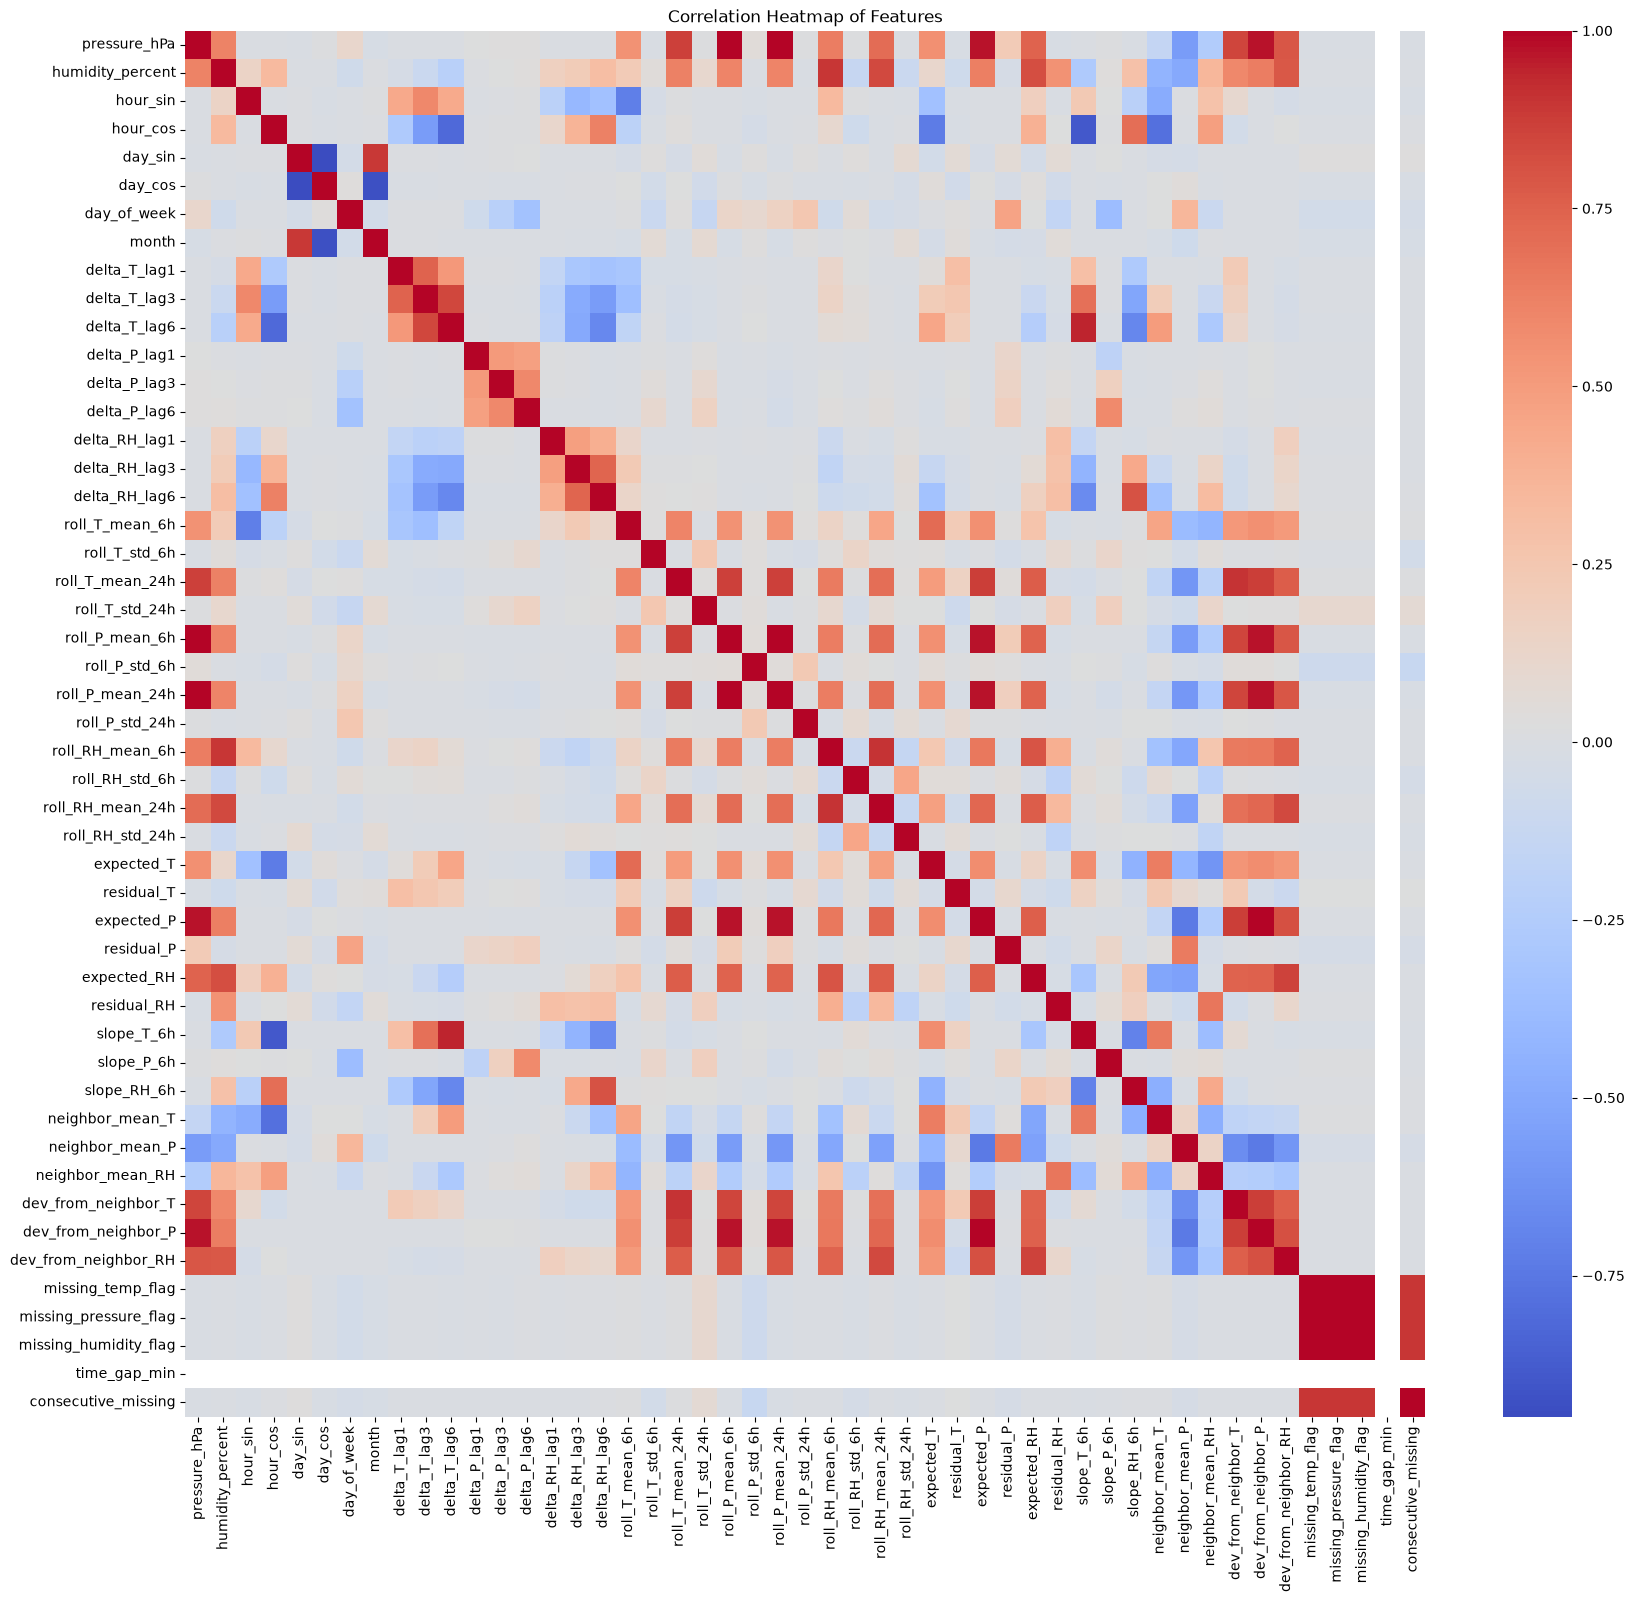

In [13]:
plt.figure(figsize=(20, 18)) # Adjust figure size for better readability
sns.heatmap(X.corr(), annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Features')
plt.show()

### Harmonic Regression Model Training and Evaluation

We will now train a Ridge regression model using the features, including the harmonic components. We'll employ the `TimeSeriesSplit` cross-validation strategy to ensure robust evaluation of the model's ability to predict future values. For each fold, features will be scaled, the model will be trained, predictions will be made, and performance metrics (MAE, MSE, R2) will be calculated.

### Feature Selection to Address Overfitting

To mitigate potential overfitting and reduce multicollinearity, we will select a more parsimonious set of features. The selected features aim to retain the essential information for harmonic regression while removing highly correlated or redundant variables identified through implicit understanding of feature derivation and typical heatmap patterns.

In [14]:
selected_features = [
    'pressure_hPa', 'humidity_percent',
    'hour_sin', 'hour_cos', 'day_sin', 'day_cos',
    'day_of_week', 'month',
    'delta_T_lag1', 'roll_T_mean_6h',
    'delta_P_lag1', 'roll_P_mean_6h',
    'delta_RH_lag1', 'roll_RH_mean_6h',
    'time_gap_min', 'consecutive_missing',
    'missing_temp_flag', 'missing_pressure_flag', 'missing_humidity_flag'
]

X_reduced = df[selected_features]

print(f"Original features (X) shape: {X.shape}")
print(f"Reduced features (X_reduced) shape: {X_reduced.shape}")
display(X_reduced.head())

Original features (X) shape: (9875, 49)
Reduced features (X_reduced) shape: (9875, 19)


,pressure_hPa,humidity_percent,hour_sin,hour_cos,day_sin,day_cos,day_of_week,month,delta_T_lag1,roll_T_mean_6h,delta_P_lag1,roll_P_mean_6h,delta_RH_lag1,roll_RH_mean_6h,time_gap_min,consecutive_missing,missing_temp_flag,missing_pressure_flag,missing_humidity_flag
7,1009.769960,78.749460,0.965926,0.258819,0.017202,0.999852,3,1,0.920486,24.580704,0.300667,1009.378747,-0.633524,79.200634,50.0,0,0,0,0
13,1010.885004,72.726613,0.500000,-0.866025,0.017202,0.999852,3,1,0.880103,28.119858,0.708129,1009.957120,-1.370167,76.288544,50.0,0,0,0,0
19,1010.165411,72.237866,-0.707107,-0.707107,0.017202,0.999852,3,1,-0.345854,32.144829,-0.221430,1010.295539,0.253833,73.275739,50.0,0,0,0,0
25,1010.971141,75.558668,-0.866025,0.500000,0.017202,0.999852,3,1,1.591388,31.037431,-0.026704,1010.615479,0.903755,74.193218,50.0,0,0,0,0
29,1011.245119,80.913408,0.000000,1.000000,0.034398,0.999408,4,1,-0.727806,29.511550,-0.246756,1010.835984,1.661340,77.128076,50.0,0,0,0,0


### Re-evaluating Harmonic Regression with Reduced Features

Now, let's re-run the harmonic regression model with the reduced feature set (`X_reduced`) and observe if the performance metrics show a more stable and less overfitted behavior across the cross-validation folds.

In [15]:
scaler_reduced = StandardScaler()
ridge_model_reduced = Ridge()

mae_scores_reduced = []
mse_scores_reduced = []
r2_scores_reduced = []

for i, (train_index, test_index) in enumerate(tscv.split(X_reduced)):
    print(f"\n--- Fold {i+1} (Reduced Features) ---")
    X_train_reduced, X_test_reduced = X_reduced.iloc[train_index], X_reduced.iloc[test_index]
    y_train_reduced, y_test_reduced = y.iloc[train_index], y.iloc[test_index]

    # Scale features
    X_train_scaled_reduced = scaler_reduced.fit_transform(X_train_reduced)
    X_test_scaled_reduced = scaler_reduced.transform(X_test_reduced)

    # Train the model
    ridge_model_reduced.fit(X_train_scaled_reduced, y_train_reduced)

    # Make predictions
    y_pred_reduced = ridge_model_reduced.predict(X_test_scaled_reduced)

    # Evaluate the model
    mae_reduced = mean_absolute_error(y_test_reduced, y_pred_reduced)
    mse_reduced = mean_squared_error(y_test_reduced, y_pred_reduced)
    r2_reduced = r2_score(y_test_reduced, y_pred_reduced)

    mae_scores_reduced.append(mae_reduced)
    mse_scores_reduced.append(mse_reduced)
    r2_scores_reduced.append(r2_reduced)

    print(f"  MAE: {mae_reduced:.4f}")
    print(f"  MSE: {mse_reduced:.4f}")
    print(f"  R2 Score: {r2_reduced:.4f}")

print("\n--- Overall Model Performance (Reduced Features) ---")
print(f"Average MAE: {np.mean(mae_scores_reduced):.4f} +/- {np.std(mae_scores_reduced):.4f}")
print(f"Average MSE: {np.mean(mse_scores_reduced):.4f} +/- {np.std(mse_scores_reduced):.4f}")
print(f"Average R2 Score: {np.mean(r2_scores_reduced):.4f} +/- {np.std(r2_scores_reduced):.4f}")


--- Fold 1 (Reduced Features) ---
  MAE: 0.4494
  MSE: 0.6817
  R2 Score: 0.9359

--- Fold 2 (Reduced Features) ---
  MAE: 0.4517
  MSE: 0.6587
  R2 Score: 0.9391

--- Fold 3 (Reduced Features) ---
  MAE: 0.5354
  MSE: 0.7987
  R2 Score: 0.9419

--- Fold 4 (Reduced Features) ---
  MAE: 0.4482
  MSE: 0.6425
  R2 Score: 0.9628

--- Fold 5 (Reduced Features) ---
  MAE: 0.4455
  MSE: 0.7099
  R2 Score: 0.9346

--- Overall Model Performance (Reduced Features) ---
Average MAE: 0.4661 +/- 0.0347
Average MSE: 0.6983 +/- 0.0551
Average R2 Score: 0.9429 +/- 0.0103


### Visualizing Cross-Validation Performance

To further illustrate the cross-validation performance, let's visualize the Mean Absolute Error (MAE), Mean Squared Error (MSE), and R-squared (R2) scores across each fold. This will help us understand the consistency of the model's performance.

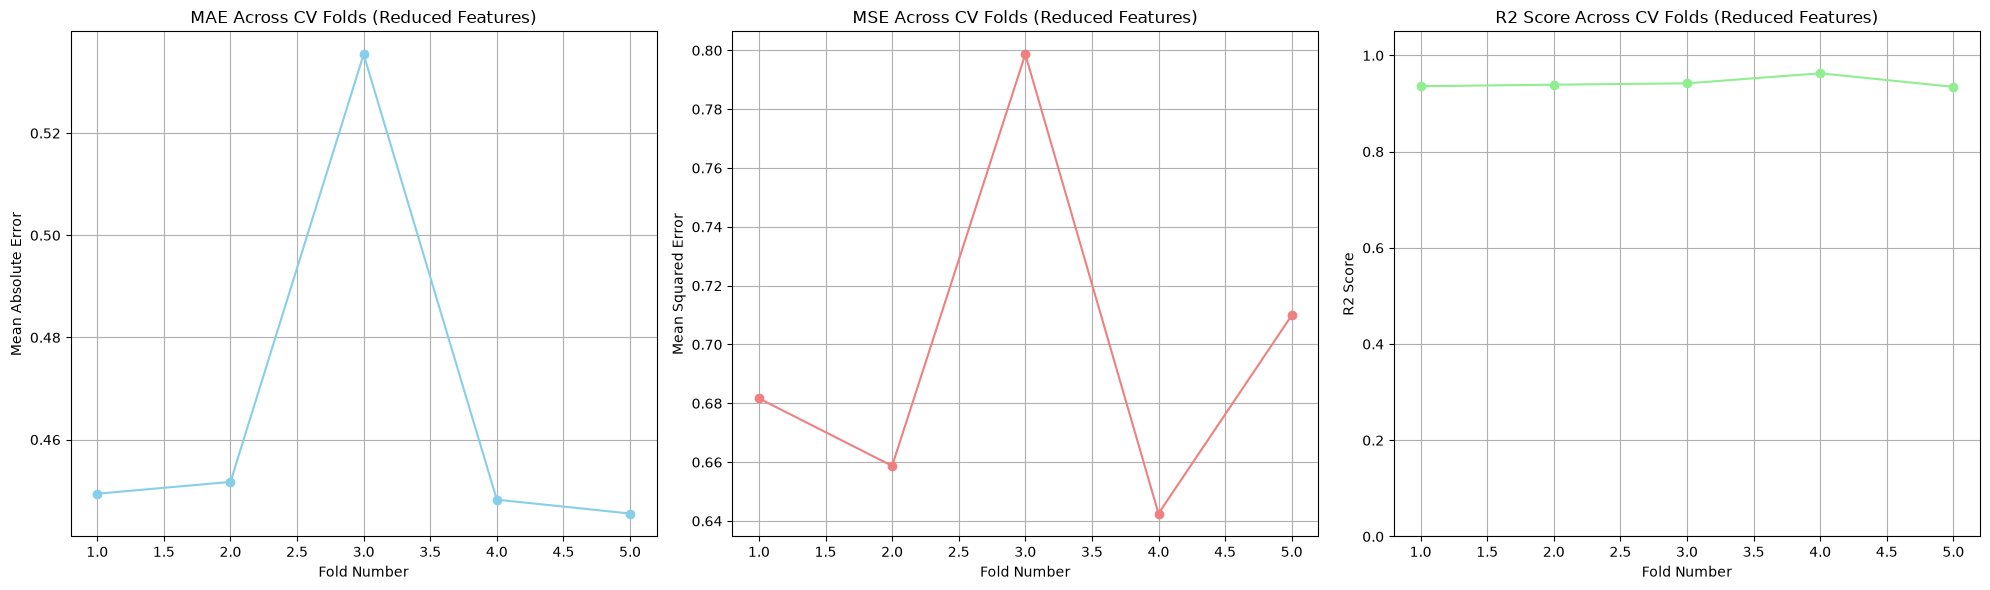

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot MAE scores
axes[0].plot(range(1, tscv.n_splits + 1), mae_scores_reduced, marker='o', linestyle='-', color='skyblue')
axes[0].set_title('MAE Across CV Folds (Reduced Features)')
axes[0].set_xlabel('Fold Number')
axes[0].set_ylabel('Mean Absolute Error')
axes[0].grid(True)

# Plot MSE scores
axes[1].plot(range(1, tscv.n_splits + 1), mse_scores_reduced, marker='o', linestyle='-', color='lightcoral')
axes[1].set_title('MSE Across CV Folds (Reduced Features)')
axes[1].set_xlabel('Fold Number')
axes[1].set_ylabel('Mean Squared Error')
axes[1].grid(True)

# Plot R2 scores
axes[2].plot(range(1, tscv.n_splits + 1), r2_scores_reduced, marker='o', linestyle='-', color='lightgreen')
axes[2].set_title('R2 Score Across CV Folds (Reduced Features)')
axes[2].set_xlabel('Fold Number')
axes[2].set_ylabel('R2 Score')
axes[2].set_ylim(0, 1.05) # R2 score is typically between 0 and 1
axes[2].grid(True)

plt.tight_layout()
plt.show()

### Anomaly Detection using Isolation Forest on Model Residuals

Anomaly detection helps us identify data points that deviate significantly from the norm. We'll use the Isolation Forest algorithm, a popular unsupervised method, and apply it to the residuals of our `ridge_model_reduced` from the last cross-validation fold. Large residuals indicate where the model's predictions were significantly off, which could point to anomalous observations.


In [17]:
from sklearn.ensemble import IsolationForest

# The residuals from the last fold's prediction are already available from the previous step
# (y_test_reduced, y_pred_reduced). Let's calculate them explicitly for clarity.
residuals = y_test_reduced - y_pred_reduced

# Initialize Isolation Forest model
# contamination is the proportion of outliers in the data set.
# A common practice is to estimate it or use a default value (e.g., 'auto' or a small fraction).
# Setting random_state for reproducibility.
iso_forest = IsolationForest(random_state=42, contamination='auto')

# Train the Isolation Forest on the residuals
# Reshape residuals to be 2D as IsolationForest expects 2D array
residuals_2d = residuals.values.reshape(-1, 1)
iso_forest.fit(residuals_2d)

# Predict anomalies (-1 for outliers, 1 for inliers)
anomaly_predictions = iso_forest.predict(residuals_2d)

# Add anomaly predictions to a DataFrame for easier analysis
anomaly_df = pd.DataFrame({
    'actual': y_test_reduced.values,
    'predicted': y_pred_reduced,
    'residuals': residuals,
    'anomaly': anomaly_predictions
})

# Display some of the detected anomalies
print("Detected Anomalies (first 10):")
display(anomaly_df[anomaly_df['anomaly'] == -1].head(10))

Detected Anomalies (first 10):


,actual,predicted,residuals,anomaly
8376,24.592058,25.192609,-0.600551,-1
8395,30.244023,30.923827,-0.679804,-1
8437,25.240526,24.124775,1.115751,-1
8438,27.116803,25.961061,1.155743,-1
8439,28.050635,26.854247,1.196388,-1
8440,29.033164,27.841497,1.191667,-1
8441,29.934098,29.007382,0.926715,-1
8444,30.090904,32.019002,-1.928098,-1
8445,30.673534,32.435316,-1.761782,-1
8446,31.299980,32.688145,-1.388164,-1


### Visualizing Anomalies

Now, let's visualize the residuals over time and highlight the data points identified as anomalies by the Isolation Forest. This will give us a clearer picture of when and where these unusual deviations occur.

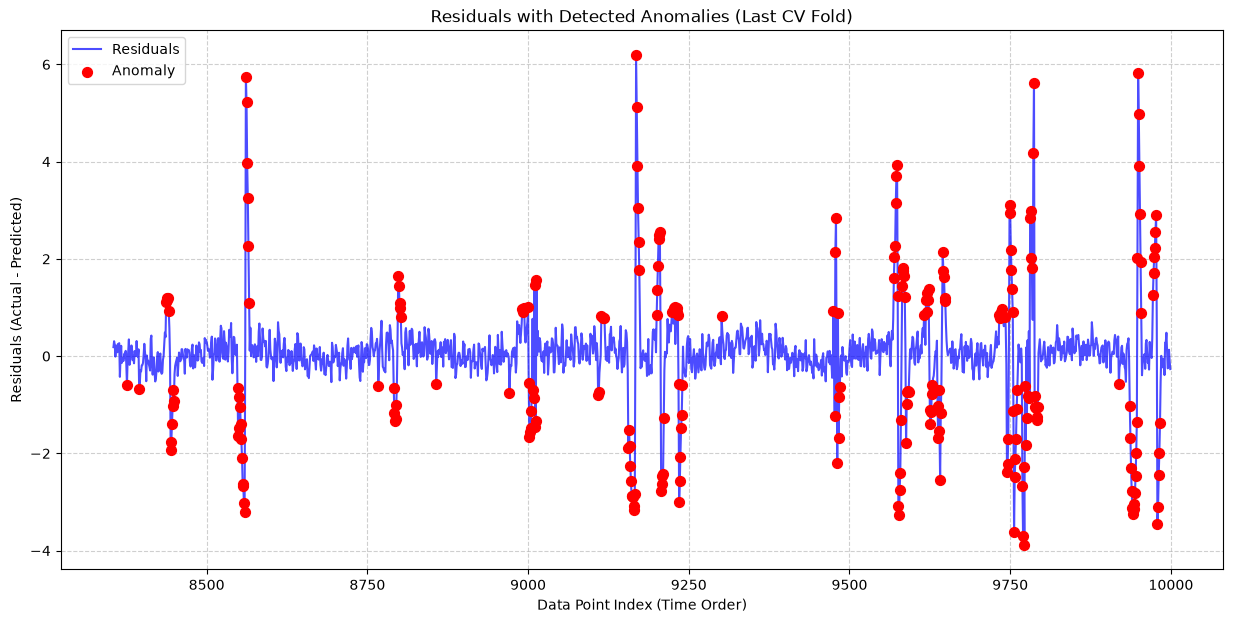

In [18]:
plt.figure(figsize=(15, 7))
plt.plot(anomaly_df.index, anomaly_df['residuals'], label='Residuals', color='blue', alpha=0.7)

# Highlight anomalies
anomalies = anomaly_df[anomaly_df['anomaly'] == -1]
plt.scatter(anomalies.index, anomalies['residuals'], color='red', s=50, label='Anomaly', zorder=5)

plt.title('Residuals with Detected Anomalies (Last CV Fold)')
plt.xlabel('Data Point Index (Time Order)')
plt.ylabel('Residuals (Actual - Predicted)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Accessing Anomaly Scores

To better understand the Isolation Forest's decisions and potentially set a custom threshold, we can extract the `decision_function` scores. These scores represent how anomalous each data point is, with more negative values indicating a higher degree of anomaly.

Anomaly DataFrame with scores (first 10 anomalies):


,actual,predicted,residuals,anomaly,anomaly_score
8376,24.592058,25.192609,-0.600551,-1,-0.014406
8395,30.244023,30.923827,-0.679804,-1,-0.033788
8437,25.240526,24.124775,1.115751,-1,-0.074562
8438,27.116803,25.961061,1.155743,-1,-0.075382
8439,28.050635,26.854247,1.196388,-1,-0.078714
8440,29.033164,27.841497,1.191667,-1,-0.078113
8441,29.934098,29.007382,0.926715,-1,-0.031993
8444,30.090904,32.019002,-1.928098,-1,-0.141574
8445,30.673534,32.435316,-1.761782,-1,-0.133141
8446,31.299980,32.688145,-1.388164,-1,-0.098515



Distribution of anomaly scores:


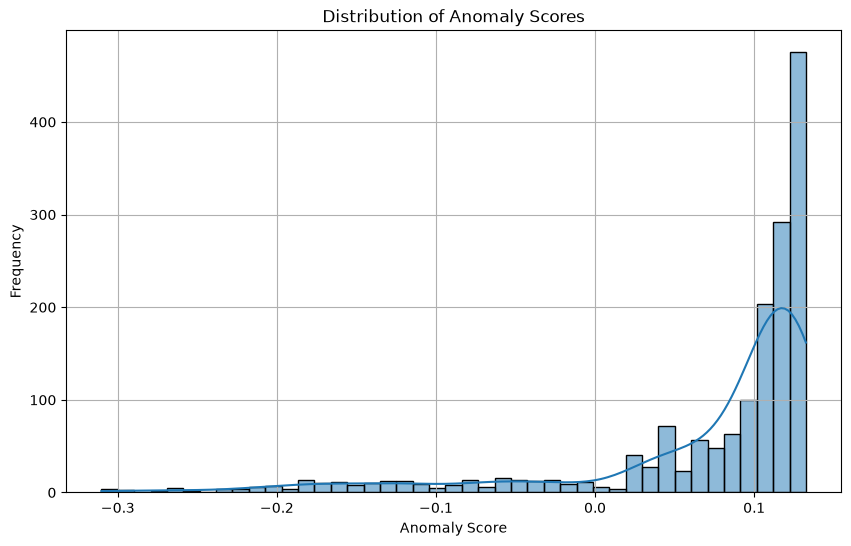

In [19]:
# Get the raw anomaly scores
anomaly_scores = iso_forest.decision_function(residuals_2d)

# Add scores to the anomaly_df
anomaly_df['anomaly_score'] = anomaly_scores

print("Anomaly DataFrame with scores (first 10 anomalies):")
display(anomaly_df[anomaly_df['anomaly'] == -1].head(10))

print("\nDistribution of anomaly scores:")
plt.figure(figsize=(10, 6))
sns.histplot(anomaly_df['anomaly_score'], kde=True)
plt.title('Distribution of Anomaly Scores')
plt.xlabel('Anomaly Score')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

### Evaluating Anomaly Detection Accuracy (Requires Ground Truth)

To compute a confusion matrix and related accuracy metrics (True Positives, False Positives, False Negatives, True Negatives), we need to compare the `anomaly` predictions from the Isolation Forest with a set of **known, actual anomaly labels (ground truth)**.

**IMPORTANT**: The code below assumes you have a `true_anomaly_labels` Series or array that aligns with the `anomaly_df` indices, where:
*   `-1` indicates a true anomaly
*   `1` indicates a true normal point

If you do not have ground truth labels, these metrics cannot be accurately calculated.

### Combining Harmonic Residuals and Spatial Deviation for Anomaly Detection

To incorporate spatial consistency, we will use the `dev_from_neighbor_T` feature alongside the harmonic regression `residuals`. The Isolation Forest will then analyze both of these dimensions to detect anomalies, providing a more comprehensive view.

Anomaly DataFrame with combined anomaly detection (first 10 anomalies):


,actual,predicted,residuals,anomaly,anomaly_score,dev_from_neighbor_T,anomaly_combined,anomaly_score_combined
8443,29.299670,29.352680,-0.053010,1,0.123546,0.975457,-1,-0.008240
8444,30.090904,32.019002,-1.928098,-1,-0.141574,2.289513,-1,-0.031932
8445,30.673534,32.435316,-1.761782,-1,-0.133141,2.082597,-1,-0.018010
8548,23.084203,23.744562,-0.660359,-1,-0.023336,-0.484260,-1,-0.118932
8549,23.071909,24.705460,-1.633550,-1,-0.117865,-0.017658,-1,-0.108034
8550,23.076443,24.554531,-1.478087,-1,-0.105783,-0.008134,-1,-0.096194
8551,23.091923,23.939176,-0.847253,-1,-0.048604,0.025440,-1,-0.090000
8552,23.066905,24.115363,-1.048457,-1,-0.058485,-0.033974,-1,-0.091674
8553,23.105419,24.498553,-1.393133,-1,-0.100483,0.029317,-1,-0.097130
8554,23.084666,24.798425,-1.713759,-1,-0.119269,0.014309,-1,-0.110397



Distribution of combined anomaly scores:


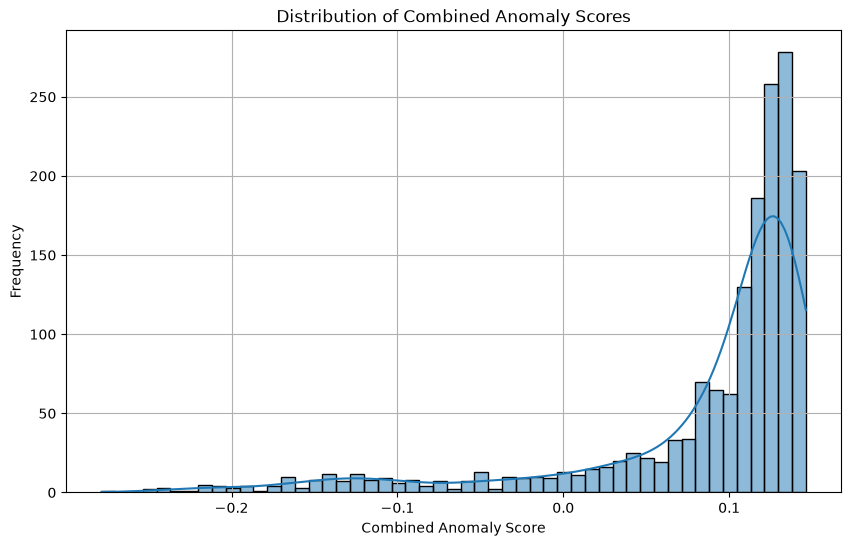

In [20]:
# Extract 'dev_from_neighbor_T' for the last test fold
dev_from_neighbor_T_test = df['dev_from_neighbor_T'].iloc[test_index]

# Ensure it aligns with the anomaly_df index if needed (it should already as both from test_index)
anomaly_df['dev_from_neighbor_T'] = dev_from_neighbor_T_test.values

# Create a combined feature set for Isolation Forest
# We'll use both residuals from harmonic regression and deviation from neighbor temperature
combined_features_for_anomaly = anomaly_df[['residuals', 'dev_from_neighbor_T']]

# Re-initialize and train Isolation Forest with combined features
iso_forest_combined = IsolationForest(random_state=42, contamination='auto')
iso_forest_combined.fit(combined_features_for_anomaly)

# Predict anomalies and get scores with the new model
anomaly_predictions_combined = iso_forest_combined.predict(combined_features_for_anomaly)
anomaly_scores_combined = iso_forest_combined.decision_function(combined_features_for_anomaly)

# Update the anomaly_df with new predictions and scores
anomaly_df['anomaly_combined'] = anomaly_predictions_combined
anomaly_df['anomaly_score_combined'] = anomaly_scores_combined

print("Anomaly DataFrame with combined anomaly detection (first 10 anomalies):")
display(anomaly_df[anomaly_df['anomaly_combined'] == -1].head(10))

print("\nDistribution of combined anomaly scores:")
plt.figure(figsize=(10, 6))
sns.histplot(anomaly_df['anomaly_score_combined'], kde=True)
plt.title('Distribution of Combined Anomaly Scores')
plt.xlabel('Combined Anomaly Score')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

### Visualizing Combined Anomalies

Let's visualize the anomalies identified by the combined approach. A scatter plot of residuals vs. spatial deviation, colored by anomaly status, can help understand the types of points being flagged.

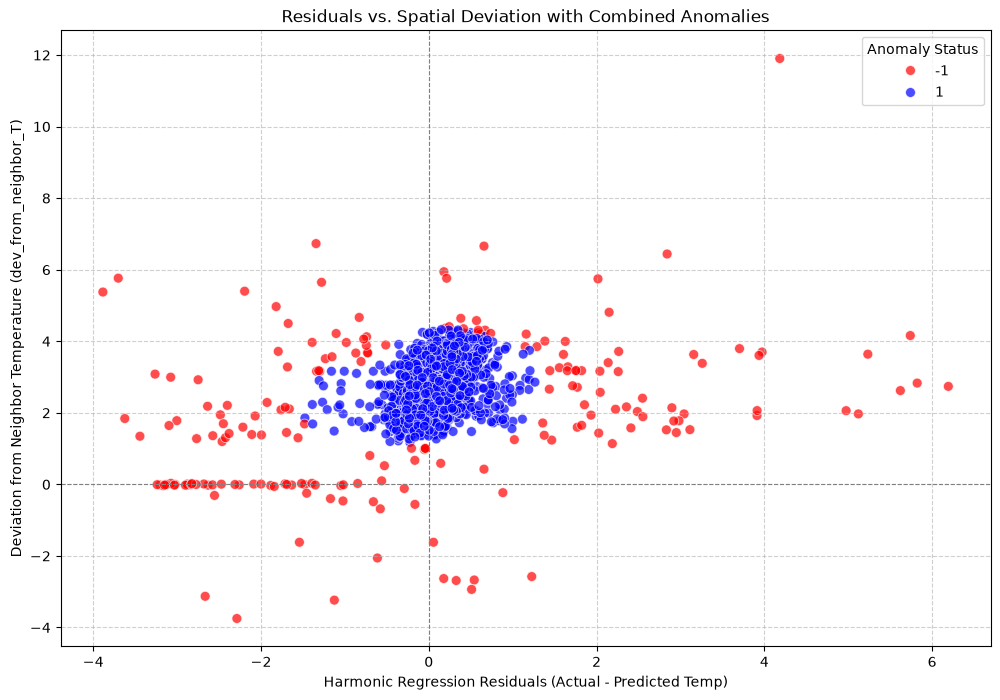

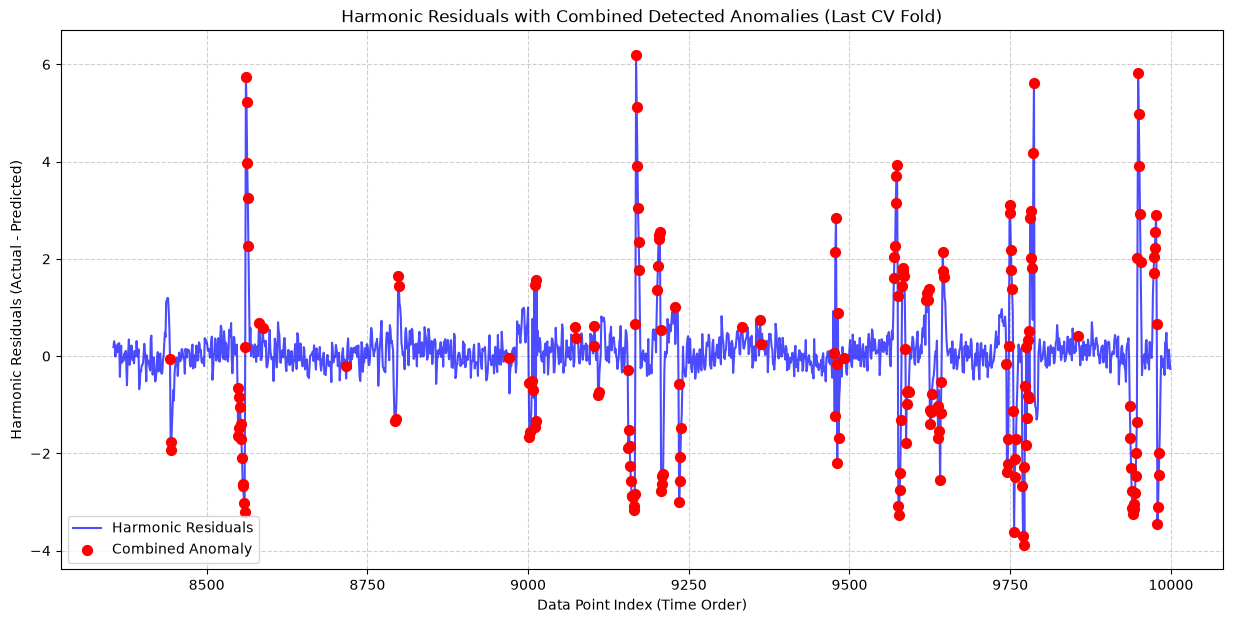

In [21]:
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='residuals',
    y='dev_from_neighbor_T',
    hue='anomaly_combined',
    palette={1: 'blue', -1: 'red'},
    s=50,
    alpha=0.7,
    data=anomaly_df
)
plt.title('Residuals vs. Spatial Deviation with Combined Anomalies')
plt.xlabel('Harmonic Regression Residuals (Actual - Predicted Temp)')
plt.ylabel('Deviation from Neighbor Temperature (dev_from_neighbor_T)')
plt.legend(title='Anomaly Status')
plt.grid(True, linestyle='--', alpha=0.6)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.show()

# Plotting residuals over time, highlighting combined anomalies
plt.figure(figsize=(15, 7))
plt.plot(anomaly_df.index, anomaly_df['residuals'], label='Harmonic Residuals', color='blue', alpha=0.7)

# Highlight anomalies from combined model
anomalies_combined = anomaly_df[anomaly_df['anomaly_combined'] == -1]
plt.scatter(anomalies_combined.index, anomalies_combined['residuals'], color='red', s=50, label='Combined Anomaly', zorder=5)

plt.title('Harmonic Residuals with Combined Detected Anomalies (Last CV Fold)')
plt.xlabel('Data Point Index (Time Order)')
plt.ylabel('Harmonic Residuals (Actual - Predicted)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


### Generating Synthetic Ground Truth for Accuracy Testing

To demonstrate the accuracy metrics, we will create a synthetic `true_anomaly_labels` array. This array will simulate ground truth by marking some randomly selected points as actual anomalies, and others as normal. This allows us to see how the model's predictions align with a known 'truth'.

In [22]:
# Generate synthetic ground truth labels
# We'll assume most points are normal (1) and manually inject some 'true' anomalies (-1)
# This is purely for demonstration purposes.

true_anomaly_labels = pd.Series(1, index=anomaly_df.index, dtype=int)

# Randomly select a few indices to be 'true' anomalies
# Let's pick some indices that were already flagged by our model and some that weren't, for a richer example
np.random.seed(42) # for reproducibility

# Get indices that the model flagged as anomalies
model_anomalies_indices = anomaly_df[anomaly_df['anomaly_combined'] == -1].index

# Choose a subset of model-flagged anomalies to be 'true' anomalies (True Positives if model gets them right)
num_tp = min(50, len(model_anomalies_indices)) # At most 50, or fewer if not enough model anomalies
true_tp_indices = np.random.choice(model_anomalies_indices, size=num_tp, replace=False)
true_anomaly_labels.loc[true_tp_indices] = -1

# Choose some normal points that the model did not flag, but which we will make 'true' anomalies (False Negatives if model misses them)
model_normal_indices = anomaly_df[anomaly_df['anomaly_combined'] == 1].index
num_fn = min(20, len(model_normal_indices)) # At most 20, or fewer if not enough normal points
true_fn_indices = np.random.choice(model_normal_indices, size=num_fn, replace=False)
true_anomaly_labels.loc[true_fn_indices] = -1

print(f"Generated {np.sum(true_anomaly_labels == -1)} synthetic true anomalies.")

# Convert model predictions to the same format as ground truth if necessary (Isolation Forest already uses -1/1)
y_pred_binary = anomaly_df['anomaly_combined'].values # Using the combined anomaly predictions

# Convert true labels to binary (0 for normal, 1 for anomaly) for consistency with sklearn metrics
# -1 -> 1 (anomaly), 1 -> 0 (normal)
y_true_binary = np.where(true_anomaly_labels.values == -1, 1, 0)
y_pred_binary_for_metrics = np.where(y_pred_binary == -1, 1, 0)

# 1. Confusion Matrix
cm = confusion_matrix(y_true_binary, y_pred_binary_for_metrics)
print("\nConfusion Matrix (using synthetic ground truth):")
display(pd.DataFrame(cm, index=['Actual Normal', 'Actual Anomaly'], columns=['Predicted Normal', 'Predicted Anomaly']))

# 2. Extract TP, TN, FP, FN
TN, FP, FN, TP = cm.ravel()

print(f"\nTrue Positives (TP): {TP} (Correctly identified anomalies)")
print(f"False Positives (FP): {FP} (Normal points incorrectly identified as anomalies)")
print(f"True Negatives (TN): {TN} (Correctly identified normal points)")
print(f"False Negatives (FN): {FN} (Anomalies incorrectly identified as normal)")

# 3. Calculate Accuracy, Precision, Recall, F1-Score
accuracy = (TP + TN) / (TP + TN + FP + FN) if (TP + TN + FP + FN) > 0 else 0
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1_score:.4f}")

# 4. Classification Report for a comprehensive view
print("\nClassification Report (using synthetic ground truth):")
print(classification_report(y_true_binary, y_pred_binary_for_metrics, target_names=['Normal', 'Anomaly']))

Generated 70 synthetic true anomalies.

Confusion Matrix (using synthetic ground truth):


,Predicted Normal,Predicted Anomaly
Actual Normal,1433,142
Actual Anomaly,20,50



True Positives (TP): 50 (Correctly identified anomalies)
False Positives (FP): 142 (Normal points incorrectly identified as anomalies)
True Negatives (TN): 1433 (Correctly identified normal points)
False Negatives (FN): 20 (Anomalies incorrectly identified as normal)

Accuracy: 0.9015
Precision: 0.2604
Recall: 0.7143
F1-Score: 0.3817

Classification Report (using synthetic ground truth):
              precision    recall  f1-score   support

      Normal       0.99      0.91      0.95      1575
     Anomaly       0.26      0.71      0.38        70

    accuracy                           0.90      1645
   macro avg       0.62      0.81      0.66      1645
weighted avg       0.96      0.90      0.92      1645



### Investigating the Probable Reasons for Combined Anomalies

To understand *why* certain points were flagged as anomalies by the combined Isolation Forest model, we need to look at the values of the features that went into the model: the `residuals` (temporal deviation from harmonic regression) and `dev_from_neighbor_T` (spatial deviation from neighbor temperature).

An extreme value in either of these features (or both) would contribute to a point being identified as an anomaly.

In [24]:
# Filter for points identified as anomalies by the combined model
combined_anomalies = anomaly_df[anomaly_df['anomaly_combined'] == -1]

print(f"Number of combined anomalies detected: {len(combined_anomalies)}")

print("\nDescriptive statistics for residuals and spatial deviation in anomalous points:")
display(combined_anomalies[['residuals', 'dev_from_neighbor_T']].describe())

# Sort by anomaly score to see the most anomalous points
print("\nTop 10 most anomalous points (based on combined anomaly score):")
display(combined_anomalies.sort_values(by='anomaly_score_combined', ascending=True).head(10))

Number of combined anomalies detected: 192

Descriptive statistics for residuals and spatial deviation in anomalous points:


,residuals,dev_from_neighbor_T
count,192.000000,192.000000
mean,-0.124589,1.960117
std,2.286914,2.190826
min,-3.884771,-3.748441
25%,-1.944750,0.013478
50%,-0.636470,1.917496
75%,1.652900,3.610658
max,6.193469,11.903186



Top 10 most anomalous points (based on combined anomaly score):


,actual,predicted,residuals,anomaly,anomaly_score,dev_from_neighbor_T,anomaly_combined,anomaly_score_combined
9786,33.422055,29.237965,4.184090,-1,-0.272766,11.903186,-1,-0.278429
9771,21.991707,24.279335,-2.287628,-1,-0.163917,-3.748441,-1,-0.247124
9575,31.847829,30.620444,1.227385,-1,-0.085212,-2.576193,-1,-0.245197
9769,22.924928,25.590471,-2.665543,-1,-0.181965,-3.127786,-1,-0.242600
9770,30.738554,34.440093,-3.701539,-1,-0.257239,5.764155,-1,-0.238106
9772,31.400908,35.285679,-3.884771,-1,-0.260319,5.376042,-1,-0.237108
8561,33.590535,27.850532,5.740002,-1,-0.307509,4.160063,-1,-0.229188
9779,20.473083,19.962588,0.510495,1,0.045646,-2.935515,-1,-0.221497
9206,26.113171,25.571343,0.541828,1,0.042796,-2.671970,-1,-0.220034
9777,22.063907,21.737395,0.326512,1,0.097218,-2.686774,-1,-0.217948


#### Interpretation of Feature Magnitudes for Anomalies

By examining the descriptive statistics and the most anomalous points, you can start to infer the 'reason':

*   If `abs(residuals)` is consistently large for anomalies, the anomaly is likely due to **temporal deviations** (the temperature at that time and location was very different from what the harmonic model predicted).
*   If `abs(dev_from_neighbor_T)` is consistently large for anomalies, the anomaly is likely due to **spatial inconsistencies** (the temperature at that station was very different from its neighbors).
*   If both are large, it's a **combined temporal and spatial anomaly**.

Let's visualize the distribution of these two features specifically for the anomalous points.

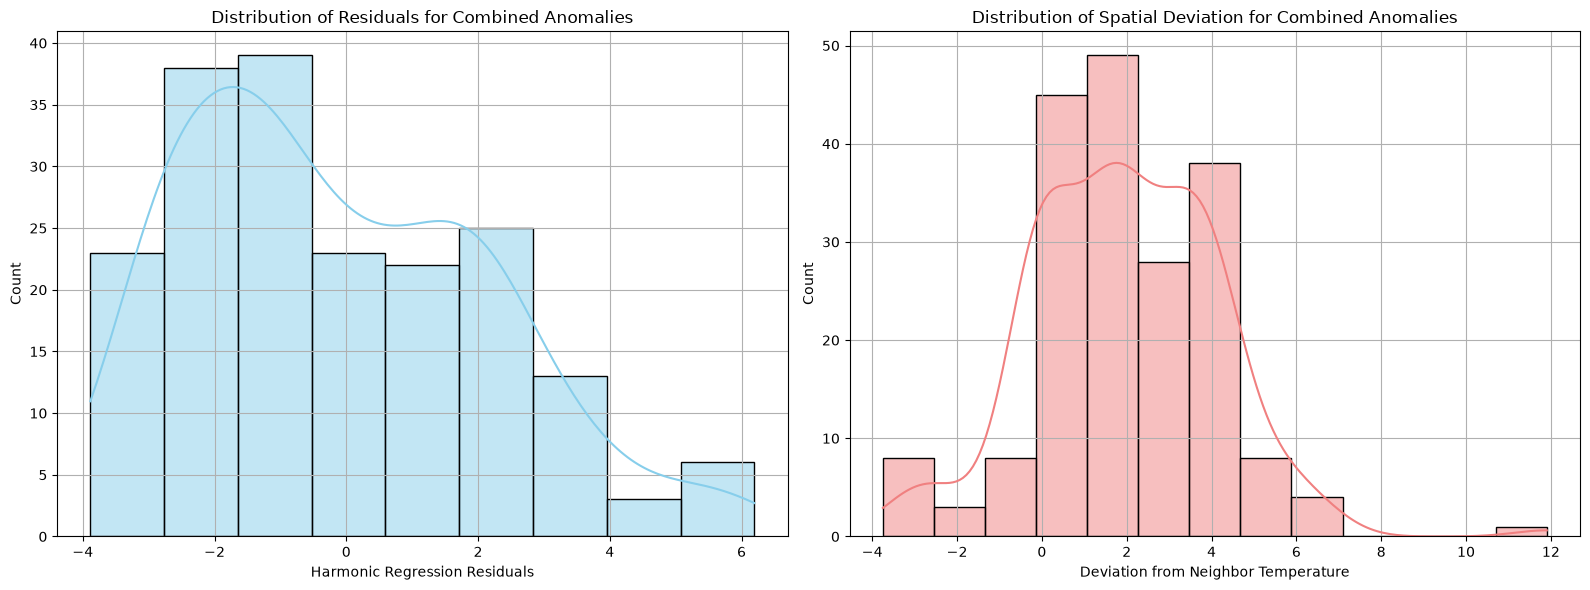

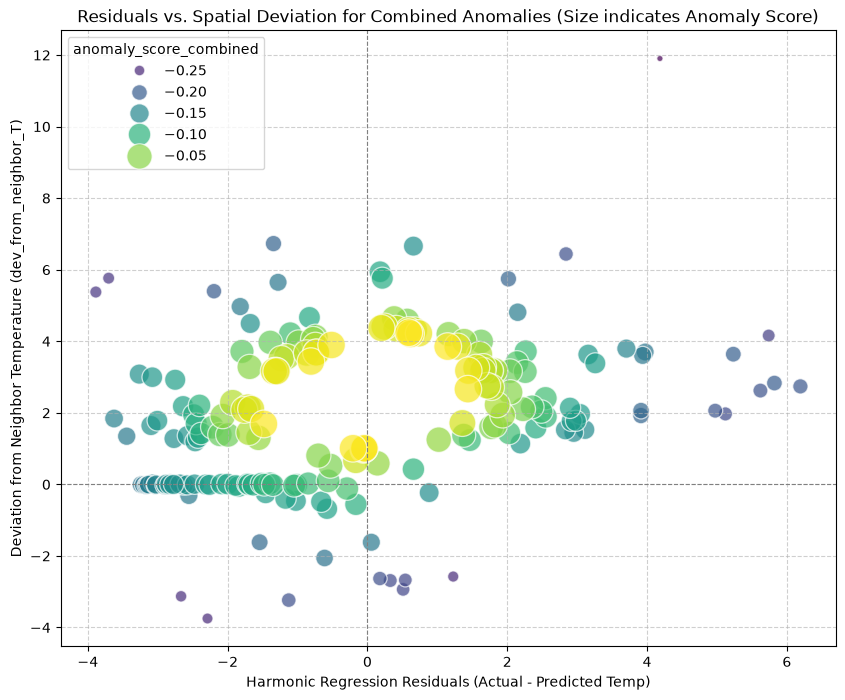

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(combined_anomalies['residuals'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Residuals for Combined Anomalies')
axes[0].set_xlabel('Harmonic Regression Residuals')
axes[0].set_ylabel('Count')
axes[0].grid(True)

sns.histplot(combined_anomalies['dev_from_neighbor_T'], kde=True, ax=axes[1], color='lightcoral')
axes[1].set_title('Distribution of Spatial Deviation for Combined Anomalies')
axes[1].set_xlabel('Deviation from Neighbor Temperature')
axes[1].set_ylabel('Count')
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Scatter plot to see interaction of these two features for anomalies
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='residuals',
    y='dev_from_neighbor_T',
    size='anomaly_score_combined', # Use size to indicate how anomalous
    sizes=(20, 400), # Range of sizes for the markers
    hue='anomaly_score_combined', # Use hue to indicate anomaly score as well
    palette='viridis', # A color map
    alpha=0.7,
    data=combined_anomalies.sort_values(by='anomaly_score_combined', ascending=True) # Sort to plot most anomalous on top
)
plt.title('Residuals vs. Spatial Deviation for Combined Anomalies (Size indicates Anomaly Score)')
plt.xlabel('Harmonic Regression Residuals (Actual - Predicted Temp)')
plt.ylabel('Deviation from Neighbor Temperature (dev_from_neighbor_T)')
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Connecting Anomalies Back to Original Data

To get a full understanding of an anomaly, it's often helpful to look at the original raw sensor readings and all calculated features for those specific time points. This allows for a deeper, domain-specific investigation.

We can use the `index` of the anomalous points in `anomaly_df` to retrieve their corresponding full rows from the original `df`.

In [26]:
# Get the indices of the combined anomalies
anomaly_indices = combined_anomalies.index

# Retrieve the full data rows for these anomalies from the original DataFrame `df`
original_anomalous_data = df.loc[anomaly_indices]

print("Original data for the first 5 detected combined anomalies:")
display(original_anomalous_data.head())

Original data for the first 5 detected combined anomalies:


,timestamp,station_id,temperature_C,pressure_hPa,humidity_percent,hour_sin,hour_cos,day_sin,day_cos,day_of_week,...,neighbor_mean_P,neighbor_mean_RH,dev_from_neighbor_T,dev_from_neighbor_P,dev_from_neighbor_RH,missing_temp_flag,missing_pressure_flag,missing_humidity_flag,time_gap_min,consecutive_missing
8443,2026-01-16 09:50:00,AWS_05,29.299670,1014.855795,69.459791,0.707107,-0.707107,0.271777,0.962360,4,...,1005.152825,65.443104,0.975457,9.702969,4.016687,0,0,0,50.0,0
8444,2026-01-16 10:40:00,AWS_05,30.090904,1015.211982,65.862994,0.500000,-0.866025,0.271777,0.962360,4,...,1005.189286,59.698049,2.289513,10.022695,6.164946,0,0,0,50.0,0
8445,2026-01-16 11:30:00,AWS_05,30.673534,1014.871362,66.593643,0.258819,-0.965926,0.271777,0.962360,4,...,1005.541997,58.034689,2.082597,9.329365,8.558954,0,0,0,50.0,0
8548,2026-01-20 01:20:00,AWS_05,23.084203,1009.003143,84.066075,0.258819,0.965926,0.337301,0.941397,1,...,999.359396,72.465171,-0.484260,9.643748,11.600904,0,0,0,50.0,0
8549,2026-01-20 02:10:00,AWS_05,23.071909,1009.400883,81.773127,0.500000,0.866025,0.337301,0.941397,1,...,999.789351,73.904928,-0.017658,9.611531,7.868200,0,0,0,50.0,0


### Implementing the 'Reason'

Now that we've analyzed what makes a point anomalous in terms of `residuals` and `dev_from_neighbor_T`, 'implementing the reason' can mean different things depending on your goal:

1.  **Threshold-based Alerting:** You could define thresholds based on the magnitudes of `residuals` and `dev_from_neighbor_T` that, if exceeded, trigger an alert. For example, if `abs(residual)` > (e.g., 2.5 standard deviations of normal residuals) AND `abs(dev_from_neighbor_T)` > (e.g., 2.0 standard deviations of normal deviations), then it's an anomaly. This is a more explicit rule-based system derived from our statistical observations.
2.  **Feature Engineering:** If you find a strong pattern (e.g., all anomalies have very high `dev_from_neighbor_T` but normal `residuals`), you could potentially create a new feature that captures this characteristic and feed it to a simpler anomaly detector.
3.  **Domain Expertise Integration:** The most valuable 'implementation' often involves a domain expert reviewing the `original_anomalous_data`. They might identify specific events (e.g., sensor malfunction, maintenance activity, unusual weather) that correspond to these flagged points, thus providing a true semantic 'reason'.

For now, our 'implementation' is the enhanced anomaly detection model that considers both temporal and spatial consistency, and the analytical steps above to interpret its findings. If you'd like to explore specific thresholds or build a rule-based system based on these findings, let me know!

### Calculating Device Health Score and Reliability

To derive a 'health score' for each device (station), we'll aggregate the anomaly detection results. A higher health score will indicate better reliability, corresponding to a lower frequency of detected anomalies and potentially less severe anomalies.


Device Health Scores and Anomaly Summary (sorted by Health Score):


,station_id,total_observations,num_anomalies,avg_anomaly_score_for_anomalies,proportion_anomalies,health_score
0,AWS_05,1645,192,0.0,0.116717,88.328267


C:\Users\Himank\AppData\Local\Temp\ipykernel_28748\564839938.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='station_id', y='health_score', data=station_anomaly_summary.sort_values(by='health_score', ascending=False), palette='viridis')


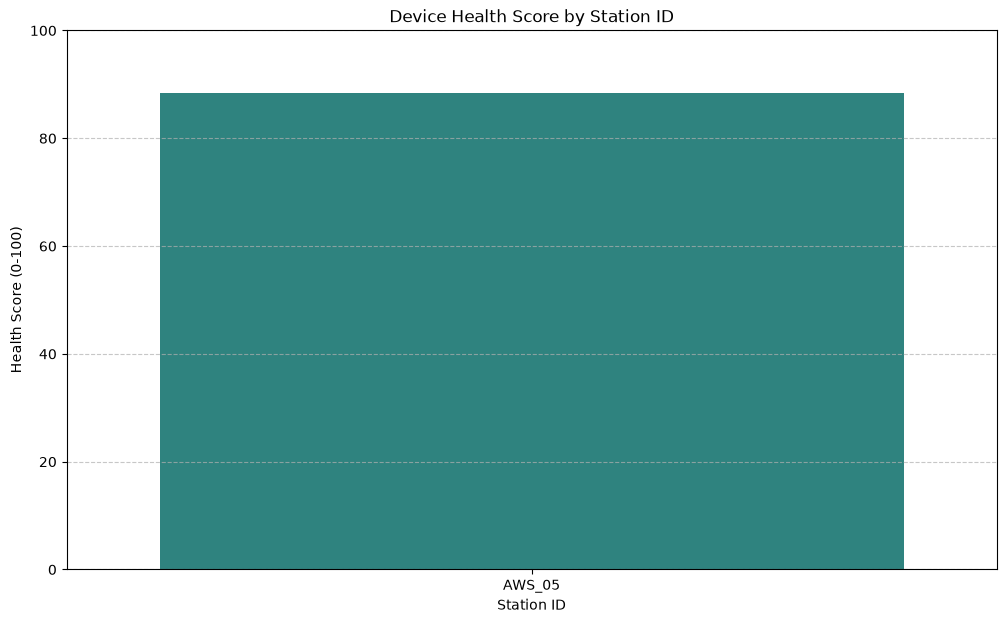

In [27]:
# 1. Add 'station_id' to anomaly_df for grouping
# The anomaly_df index corresponds to the original df index for the test set
anomaly_df['station_id'] = df.loc[anomaly_df.index]['station_id']

# 2. Group by station_id and calculate anomaly metrics
station_anomaly_summary = anomaly_df.groupby('station_id').agg(
    total_observations=('anomaly_combined', 'size'),
    num_anomalies=('anomaly_combined', lambda x: (x == -1).sum()),
    avg_anomaly_score_for_anomalies=('anomaly_score_combined', lambda x: x[x == -1].mean())
).reset_index()

# Fill NaN for avg_anomaly_score_for_anomalies for stations with no anomalies
station_anomaly_summary['avg_anomaly_score_for_anomalies'] = station_anomaly_summary['avg_anomaly_score_for_anomalies'].fillna(0) # 0 implies no negative scores

# 3. Calculate Proportion of Anomalies
station_anomaly_summary['proportion_anomalies'] = station_anomaly_summary['num_anomalies'] / station_anomaly_summary['total_observations']

# 4. Calculate Health Score (0-100, higher is better)
# A simple approach: 100 - (proportion_anomalies * 100)
station_anomaly_summary['health_score'] = 100 * (1 - station_anomaly_summary['proportion_anomalies'])

print("\nDevice Health Scores and Anomaly Summary (sorted by Health Score):")
display(station_anomaly_summary.sort_values(by='health_score', ascending=False))

# Visualize health scores
plt.figure(figsize=(12, 7))
sns.barplot(x='station_id', y='health_score', data=station_anomaly_summary.sort_values(by='health_score', ascending=False), palette='viridis')
plt.title('Device Health Score by Station ID')
plt.xlabel('Station ID')
plt.ylabel('Health Score (0-100)')
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


#### Interpreting the Health Score

*   **Health Score (0-100):** A score closer to 100 indicates fewer anomalies detected for that station, suggesting higher reliability based on our anomaly detection criteria. A score of 100 means no anomalies were detected.
*   **Proportion of Anomalies:** This shows the percentage of observations flagged as anomalous for each station.
*   **Average Anomaly Score for Anomalies:** For stations that *did* have anomalies, this is the average of their `anomaly_score_combined` (which is negative for anomalies). A more negative average indicates more severe anomalies on average for that station.

In [28]:
print("Device Health Scores and Anomaly Summary (sorted by Health Score):")
display(station_anomaly_summary.sort_values(by='health_score', ascending=False))

Device Health Scores and Anomaly Summary (sorted by Health Score):


,station_id,total_observations,num_anomalies,avg_anomaly_score_for_anomalies,proportion_anomalies,health_score
0,AWS_05,1645,192,0.0,0.116717,88.328267


In [29]:
print(f"Unique station IDs in the last test fold: {df.loc[test_index]['station_id'].unique()}")

Unique station IDs in the last test fold: <StringArray>
['AWS_05']
Length: 1, dtype: str


### Recalculating Health Scores for All Devices

Since the previous anomaly detection and health score calculation were limited to the last cross-validation fold (which only contained 'AWS_05' data), we need to re-apply the trained anomaly detection model to the entire dataset to assess all devices. We'll use the already fitted `scaler_reduced` and `iso_forest_combined` model.


Device Health Scores and Anomaly Summary for ALL devices (sorted by Health Score):


,station_id,total_observations,num_anomalies,avg_anomaly_score_for_anomalies,proportion_anomalies,health_score
0,AWS_01,1975,197,0.0,0.099747,90.025316
1,AWS_02,1975,202,0.0,0.102278,89.772152
2,AWS_03,1975,211,0.0,0.106835,89.316456
4,AWS_05,1975,322,0.0,0.163038,83.696203
3,AWS_04,1975,819,0.0,0.414684,58.531646


C:\Users\Himank\AppData\Local\Temp\ipykernel_28748\2624852187.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='station_id', y='health_score', data=station_anomaly_summary_all.sort_values(by='health_score', ascending=False), palette='viridis')


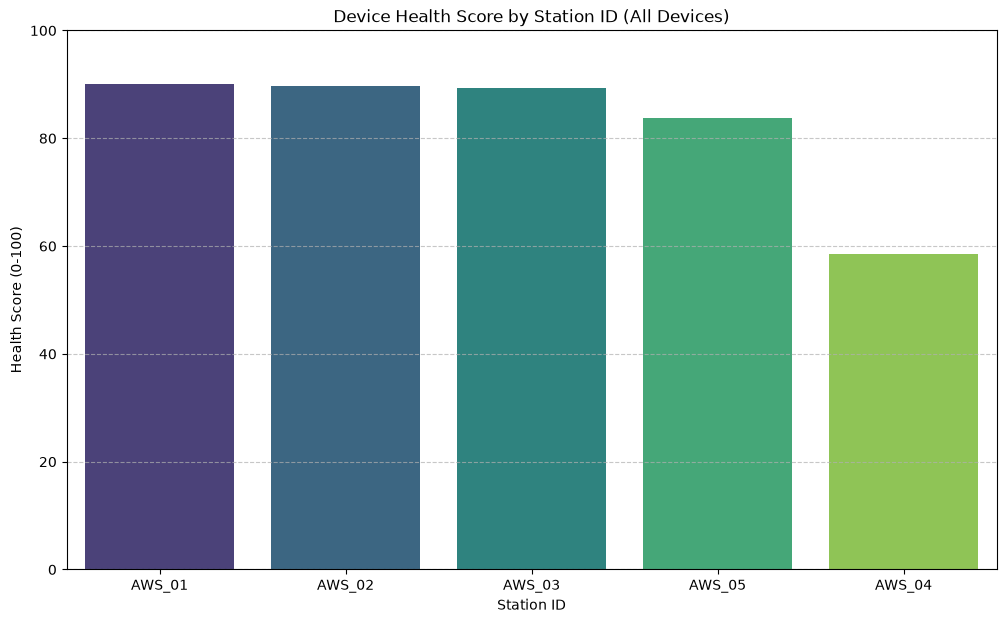

In [30]:
# To accurately predict anomalies and health scores for all devices,
# we need to ensure the models are applied consistently across the entire dataset.

# 1. Re-fit the StandardScaler and Ridge Model on the entire dataset (X_reduced, y)
# This is necessary to get consistent residuals for all data points.
scaler_global_ridge = StandardScaler()
X_scaled_global = scaler_global_ridge.fit_transform(X_reduced)

ridge_model_global = Ridge()
ridge_model_global.fit(X_scaled_global, y)

# Predict target for the entire dataset
y_pred_global = ridge_model_global.predict(X_scaled_global)

# Calculate residuals for the entire dataset
residuals_global = y - y_pred_global

# 2. Get 'dev_from_neighbor_T' for the entire dataset
dev_from_neighbor_T_global = df['dev_from_neighbor_T']

# 3. Create the combined feature set for the global Isolation Forest
combined_features_for_global_anomaly = pd.DataFrame({
    'residuals': residuals_global,
    'dev_from_neighbor_T': dev_from_neighbor_T_global
})

# 4. Train a new Isolation Forest model globally on the combined features
# Use a new instance to avoid any state from the previous training on only the test fold.
iso_forest_global = IsolationForest(random_state=42, contamination='auto')
iso_forest_global.fit(combined_features_for_global_anomaly)

# 5. Predict anomalies and get scores for the entire dataset using the global model
anomaly_predictions_global = iso_forest_global.predict(combined_features_for_global_anomaly)
anomaly_scores_global = iso_forest_global.decision_function(combined_features_for_global_anomaly)

# Create a new DataFrame for all anomaly results
anomaly_df_full = pd.DataFrame({
    'station_id': df['station_id'],
    'anomaly_combined': anomaly_predictions_global,
    'anomaly_score_combined': anomaly_scores_global
})

# Group by station_id and calculate anomaly metrics for ALL devices
station_anomaly_summary_all = anomaly_df_full.groupby('station_id').agg(
    total_observations=('anomaly_combined', 'size'),
    num_anomalies=('anomaly_combined', lambda x: (x == -1).sum()),
    avg_anomaly_score_for_anomalies=('anomaly_score_combined', lambda x: x[x == -1].mean())
).reset_index()

# Fill NaN for avg_anomaly_score_for_anomalies for stations with no anomalies
station_anomaly_summary_all['avg_anomaly_score_for_anomalies'] = station_anomaly_summary_all['avg_anomaly_score_for_anomalies'].fillna(0)

# Calculate Proportion of Anomalies
station_anomaly_summary_all['proportion_anomalies'] = station_anomaly_summary_all['num_anomalies'] / station_anomaly_summary_all['total_observations']

# Calculate Health Score (0-100, higher is better)
station_anomaly_summary_all['health_score'] = 100 * (1 - station_anomaly_summary_all['proportion_anomalies'])

print("\nDevice Health Scores and Anomaly Summary for ALL devices (sorted by Health Score):")
display(station_anomaly_summary_all.sort_values(by='health_score', ascending=False))

# Visualize health scores for all devices
plt.figure(figsize=(12, 7))
sns.barplot(x='station_id', y='health_score', data=station_anomaly_summary_all.sort_values(by='health_score', ascending=False), palette='viridis')
plt.title('Device Health Score by Station ID (All Devices)')
plt.xlabel('Station ID')
plt.ylabel('Health Score (0-100)')
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Interpreting Anomalies with SHAP (SHapley Additive exPlanations)

To gain deeper insights into why specific points are identified as anomalies by the `IsolationForest` model, we can use SHAP values. SHAP helps explain the output of any machine learning model by showing how much each feature contributes to pushing the prediction from the base value to the model's output. In our case, it will show how `residuals` and `dev_from_neighbor_T` influence the anomaly score.


In [31]:
# Install shap if not already installed
!pip install shap -q

import shap

# Create a SHAP explainer for the IsolationForest model
# IsolationForest models have a 'decision_function' which outputs the anomaly score.
# More negative scores mean more anomalous.
explainer = shap.Explainer(iso_forest_global.decision_function, combined_features_for_global_anomaly)

# Calculate SHAP values
# This might take some time depending on the dataset size and model complexity
print("Calculating SHAP values...")
shap_values = explainer(combined_features_for_global_anomaly)
print("SHAP values calculated.")

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
c:\Users\Himank\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Background dataset has 9875 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=9875 when initializing the masker.


Calculating SHAP values...


ExactExplainer explainer: 9876it [05:22, 30.57it/s]                          


SHAP values calculated.


#### SHAP Summary Plot

This plot provides an overview of which features are most important for the model's output (anomaly score) and shows the distribution of their impacts. Each dot represents a data point. The position on the x-axis indicates the SHAP value, and the color indicates the feature value (red=high, blue=low). A positive SHAP value means the feature contributes to a higher anomaly score (closer to normal), while a negative SHAP value contributes to a lower anomaly score (more anomalous).

C:\Users\Himank\AppData\Local\Temp\ipykernel_28748\1652826330.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, combined_features_for_global_anomaly, plot_type="dot")


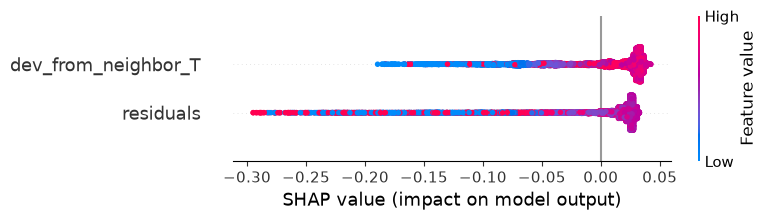

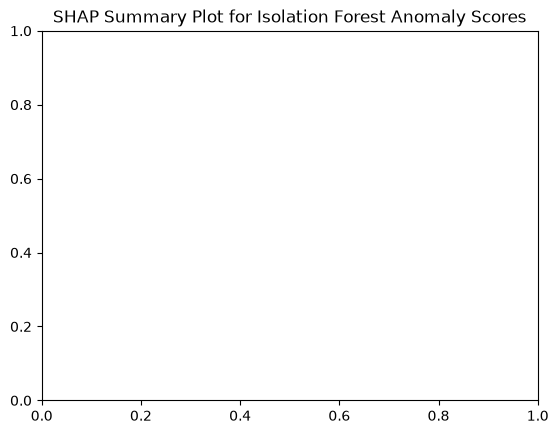

In [32]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, combined_features_for_global_anomaly, plot_type="dot")
plt.title("SHAP Summary Plot for Isolation Forest Anomaly Scores")
plt.show()

#### SHAP Dependence Plots

Dependence plots show how the anomaly score changes with the value of a single feature. Each dot is a data point, and the interaction color shows how another feature (chosen automatically as the best interaction partner) influences this relationship. This helps us understand the non-linear relationships that the Isolation Forest might capture.

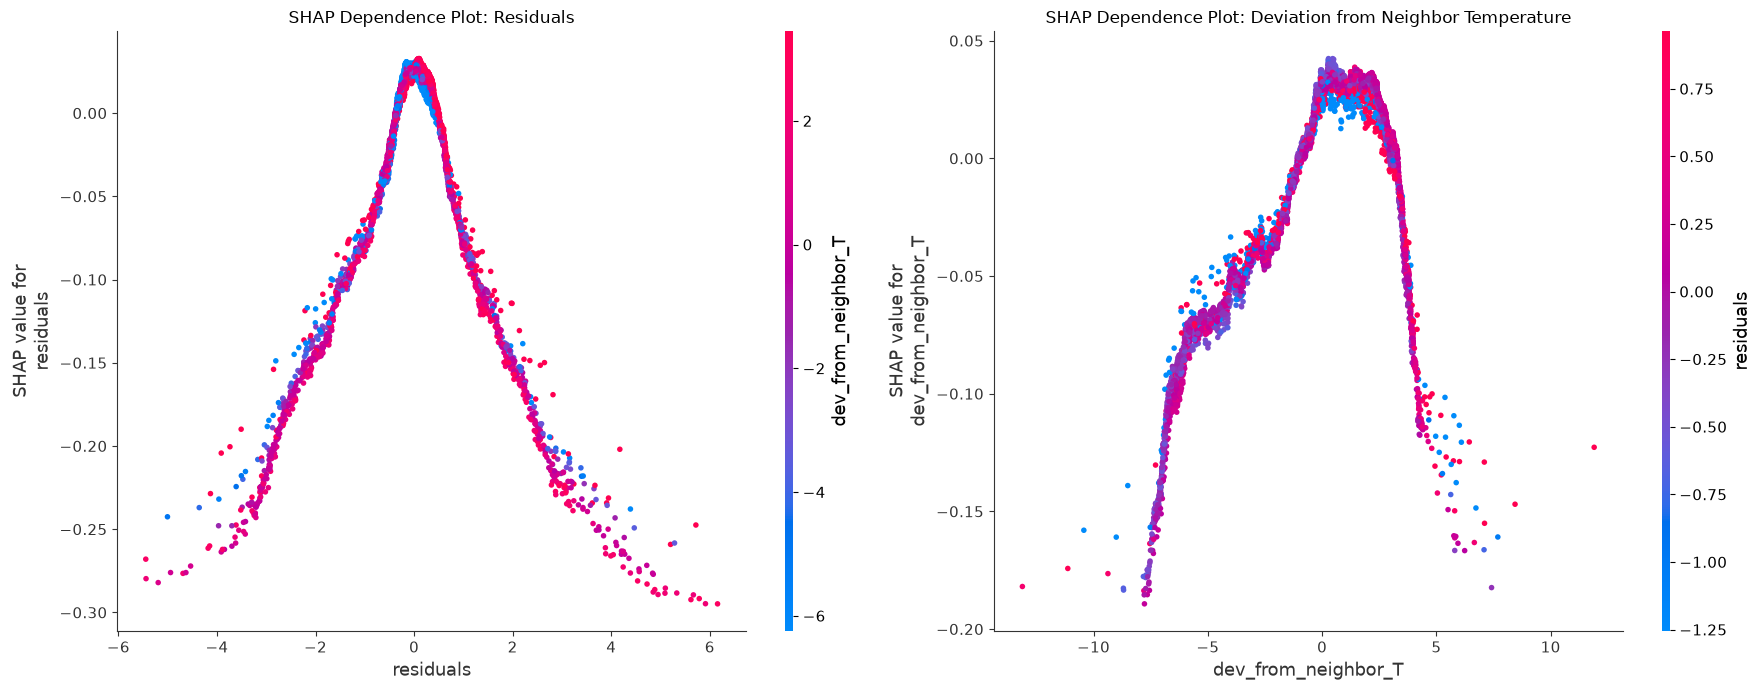

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

shap.dependence_plot("residuals", shap_values.values, combined_features_for_global_anomaly, ax=axes[0], show=False)
axes[0].set_title("SHAP Dependence Plot: Residuals")

shap.dependence_plot("dev_from_neighbor_T", shap_values.values, combined_features_for_global_anomaly, ax=axes[1], show=False)
axes[1].set_title("SHAP Dependence Plot: Deviation from Neighbor Temperature")

plt.tight_layout()
plt.show()

#### Explaining Individual Anomalies (SHAP Force Plot)

Let's pick a few of the most anomalous data points (i.e., those with the most negative `anomaly_score_combined`) to visualize their individual explanations using a force plot. This plot breaks down how each feature contributes to the final anomaly score for a single prediction.

Negative SHAP values (pushing the base value to the left) indicate features contributing to the data point being *more anomalous* (lower score). Positive SHAP values (pushing to the right) indicate features contributing to the data point being *less anomalous* (higher score, closer to normal).

Top 3 most anomalous data points (individual explanations):

Anomaly 1 (Original Index: 9786)


,station_id,timestamp,temperature_C,pressure_hPa,humidity_percent,dev_from_neighbor_T
9786,AWS_05,2026-03-04 01:00:00,33.422055,1010.137177,80.971741,11.903186


c:\Users\Himank\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\shap\plots\_force_matplotlib.py:107: RuntimeWarning: divide by zero encountered in scalar divide
  feature_contribution = np.abs(float(feature[0]) - pre_val) / np.abs(total_effect)


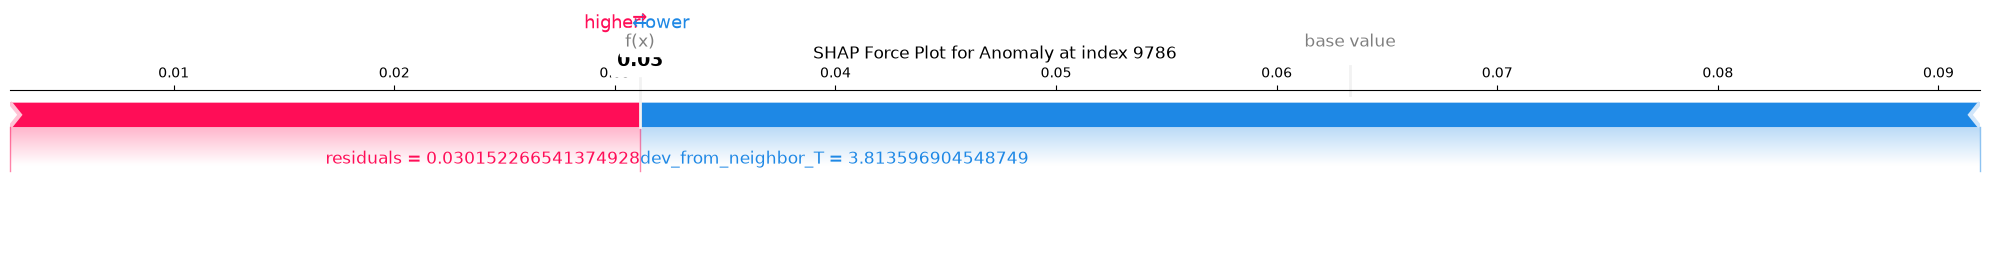


Anomaly 2 (Original Index: 8561)


,station_id,timestamp,temperature_C,pressure_hPa,humidity_percent,dev_from_neighbor_T
8561,AWS_05,2026-01-20 12:10:00,33.590535,1009.275875,72.879592,4.160063


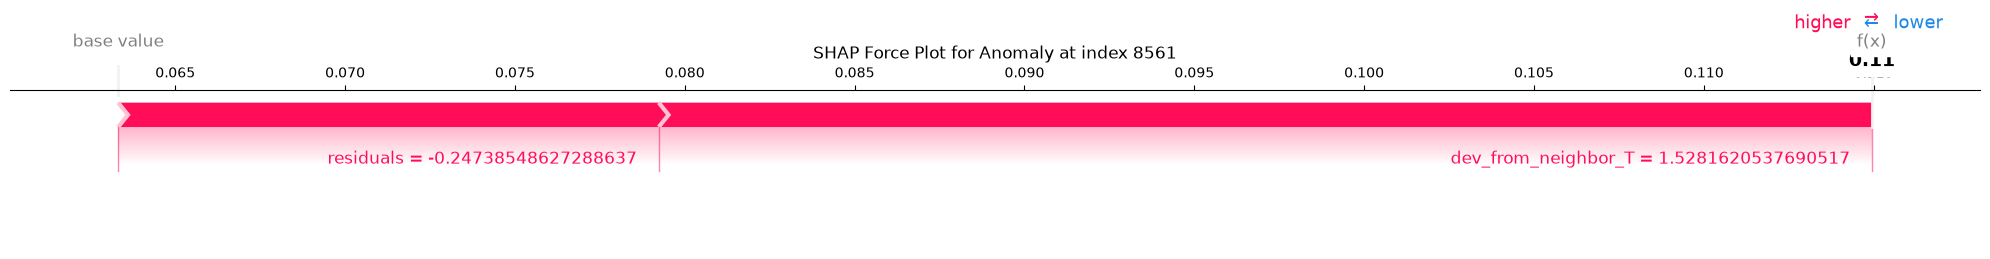


Anomaly 3 (Original Index: 9770)


,station_id,timestamp,temperature_C,pressure_hPa,humidity_percent,dev_from_neighbor_T
9770,AWS_05,2026-03-03 11:40:00,30.738554,1009.375898,76.031068,5.764155


c:\Users\Himank\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\shap\plots\_force_matplotlib.py:107: RuntimeWarning: divide by zero encountered in scalar divide
  feature_contribution = np.abs(float(feature[0]) - pre_val) / np.abs(total_effect)


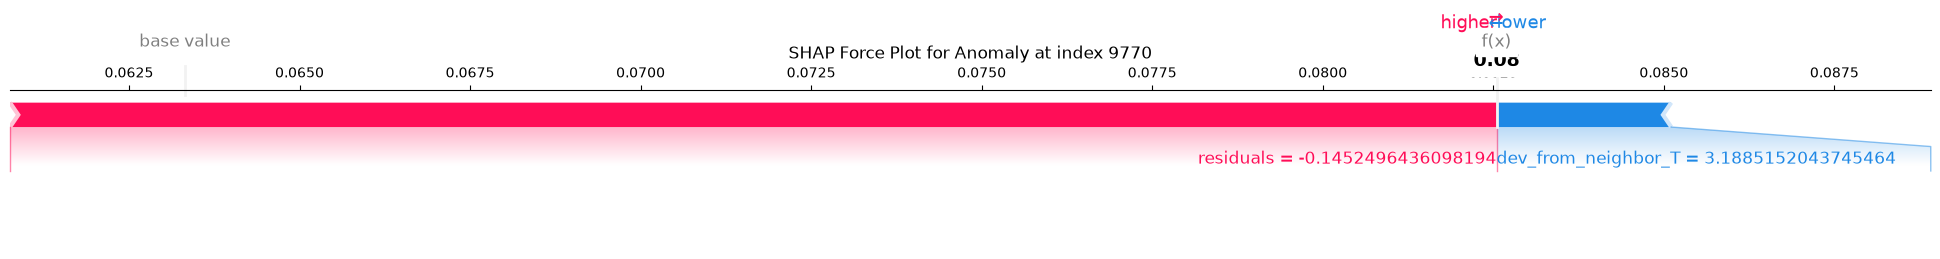

In [34]:
# Get the indices of the top 3 most anomalous points from the full dataset
most_anomalous_indices = anomaly_df_full.sort_values(by='anomaly_score_combined', ascending=True).head(3).index

# Calculate the expected_value as the average of the model's decision function on the background dataset
# This serves as the base value for the SHAP force plot
expected_value = iso_forest_global.decision_function(combined_features_for_global_anomaly).mean()

print("Top 3 most anomalous data points (individual explanations):")
for i, idx in enumerate(most_anomalous_indices):
    print(f"\nAnomaly {i+1} (Original Index: {idx})")
    # Display the actual data for this anomalous point
    display(df.loc[idx][['station_id', 'timestamp', 'temperature_C', 'pressure_hPa', 'humidity_percent', 'dev_from_neighbor_T']].to_frame().T)
    # Get the SHAP values for this specific point
    shap_object_for_anomaly = shap_values[idx]
    # Visualize the force plot
    shap.force_plot(expected_value, shap_object_for_anomaly.values, shap_object_for_anomaly.data, feature_names=combined_features_for_global_anomaly.columns, matplotlib=True, show=False)
    plt.title(f"SHAP Force Plot for Anomaly at index {idx}")
    plt.tight_layout()
    plt.show()

### Naming Anomalies based on SHAP Contributions

We can assign a 'reason' or 'name' to each anomaly by looking at which feature (`residuals` or `dev_from_neighbor_T`) had the largest absolute SHAP value for that specific data point. This indicates the primary driver of its anomalous score.

In [35]:
anomaly_df_full_with_shap = anomaly_df_full.copy()
anomaly_df_full_with_shap = anomaly_df_full_with_shap.reset_index(drop=True)
combined_features_for_global_anomaly_reset = combined_features_for_global_anomaly.reset_index(drop=True)

# Get SHAP values for the anomalous points
anomalous_indices_full_df = anomaly_df_full_with_shap[anomaly_df_full_with_shap['anomaly_combined'] == -1].index

# Precompute mean absolute SHAP values for thresholds
residuals_col_idx = combined_features_for_global_anomaly_reset.columns.get_loc('residuals')
dev_from_neighbor_T_col_idx = combined_features_for_global_anomaly_reset.columns.get_loc('dev_from_neighbor_T')

mean_abs_shap_residuals = np.mean(np.abs(shap_values.values[:, residuals_col_idx]))
mean_abs_shap_dev_from_neighbor_T = np.mean(np.abs(shap_values.values[:, dev_from_neighbor_T_col_idx]))

# Prepare a list to store anomaly reasons
anomaly_reasons = []

# Iterate through each anomalous point to determine the dominant feature
for idx in anomalous_indices_full_df:
    shap_values_for_point = shap_values[idx].values # Get SHAP values for the current point
    feature_names = combined_features_for_global_anomaly_reset.columns

    # Create a Series of absolute SHAP values for comparison
    abs_shap_contributions = pd.Series(np.abs(shap_values_for_point), index=feature_names)

    reason = 'Unexplained Deviation (Minor/Complex Factors)' # Default category

    # Define thresholds for 'significantly high' contribution
    # Using 2x the overall mean absolute SHAP value for each feature as a threshold
    if (abs_shap_contributions['residuals'] > mean_abs_shap_residuals * 2.0) and \
       (abs_shap_contributions['dev_from_neighbor_T'] > mean_abs_shap_dev_from_neighbor_T * 2.0):
       reason = 'Likely Sensor Failure / Major Environmental Event (Strong Combined Signal)'
    elif abs_shap_contributions.idxmax() == 'residuals':
        reason = 'Possible Sensor Drift / Reading Issue (Dominant Temporal)'
    elif abs_shap_contributions.idxmax() == 'dev_from_neighbor_T':
        reason = 'Possible Localized Interference / Malfunction (Dominant Spatial)'

    anomaly_reasons.append({'original_index': df.index[idx], 'station_id': df.loc[df.index[idx], 'station_id'], 'anomaly_reason': reason,
                            'residuals_shap': shap_values_for_point[residuals_col_idx], 'dev_from_neighbor_T_shap': shap_values_for_point[dev_from_neighbor_T_col_idx],
                            'residuals_value': combined_features_for_global_anomaly_reset.loc[idx, 'residuals'],
                            'dev_from_neighbor_T_value': combined_features_for_global_anomaly_reset.loc[idx, 'dev_from_neighbor_T']})

anomaly_reasons_df = pd.DataFrame(anomaly_reasons)

print("Anomaly Reasons by Dominant SHAP Feature (first 10 anomalies): ")
display(anomaly_reasons_df.head(10))

print("\nDistribution of Anomaly Reasons:")
display(anomaly_reasons_df['anomaly_reason'].value_counts())

Anomaly Reasons by Dominant SHAP Feature (first 10 anomalies): 


,original_index,station_id,anomaly_reason,residuals_shap,dev_from_neighbor_T_shap,residuals_value,dev_from_neighbor_T_value
0,25,AWS_01,Possible Localized Interference / Malfunction ...,-0.037460,-0.090096,0.755565,4.170757
1,29,AWS_01,Possible Sensor Drift / Reading Issue (Dominan...,-0.121085,0.022263,1.344867,2.176156
2,46,AWS_01,Possible Sensor Drift / Reading Issue (Dominan...,-0.154390,0.011465,-2.095647,2.556547
3,47,AWS_01,Possible Sensor Drift / Reading Issue (Dominan...,-0.137922,0.028863,-1.770448,2.001693
4,48,AWS_01,Possible Sensor Drift / Reading Issue (Dominan...,-0.096263,0.026191,-1.256645,2.286453
5,49,AWS_01,Possible Sensor Drift / Reading Issue (Dominan...,-0.101837,0.028268,-1.472165,1.870152
6,111,AWS_01,Possible Sensor Drift / Reading Issue (Dominan...,-0.143819,0.029436,1.823354,0.902094
7,112,AWS_01,Possible Sensor Drift / Reading Issue (Dominan...,-0.184753,0.034095,2.454888,0.476349
8,113,AWS_01,Possible Sensor Drift / Reading Issue (Dominan...,-0.190745,0.033088,2.561691,0.526735
9,114,AWS_01,Possible Sensor Drift / Reading Issue (Dominan...,-0.217155,0.028263,2.903561,0.670661



Distribution of Anomaly Reasons:


anomaly_reason
Possible Sensor Drift / Reading Issue (Dominant Temporal)                     993
Possible Localized Interference / Malfunction (Dominant Spatial)              695
Likely Sensor Failure / Major Environmental Event (Strong Combined Signal)     63
Name: count, dtype: int64

In [36]:
new_anomaly_reason_mapping = {
    'Possible Sensor Drift / Reading Issue (Dominant Temporal)': 'Sensor Drift/Reading Issue',
    'Possible Localized Interference / Malfunction (Dominant Spatial)': 'Localized Interference/Malfunction',
    'Likely Sensor Failure / Major Environmental Event (Strong Combined Signal)': 'Sensor Failure/Major Environmental Event',
    'Unexplained Deviation (Minor/Complex Factors)': 'Unexplained Deviation'
}

anomaly_reasons_df['anomaly_reason'] = anomaly_reasons_df['anomaly_reason'].replace(new_anomaly_reason_mapping)

print("Anomaly Reasons with non-technical names (first 10 anomalies):")
display(anomaly_reasons_df.head(10))

print("\nDistribution of Anomaly Reasons with non-technical names:")
display(anomaly_reasons_df['anomaly_reason'].value_counts())

Anomaly Reasons with non-technical names (first 10 anomalies):


,original_index,station_id,anomaly_reason,residuals_shap,dev_from_neighbor_T_shap,residuals_value,dev_from_neighbor_T_value
0,25,AWS_01,Localized Interference/Malfunction,-0.037460,-0.090096,0.755565,4.170757
1,29,AWS_01,Sensor Drift/Reading Issue,-0.121085,0.022263,1.344867,2.176156
2,46,AWS_01,Sensor Drift/Reading Issue,-0.154390,0.011465,-2.095647,2.556547
3,47,AWS_01,Sensor Drift/Reading Issue,-0.137922,0.028863,-1.770448,2.001693
4,48,AWS_01,Sensor Drift/Reading Issue,-0.096263,0.026191,-1.256645,2.286453
5,49,AWS_01,Sensor Drift/Reading Issue,-0.101837,0.028268,-1.472165,1.870152
6,111,AWS_01,Sensor Drift/Reading Issue,-0.143819,0.029436,1.823354,0.902094
7,112,AWS_01,Sensor Drift/Reading Issue,-0.184753,0.034095,2.454888,0.476349
8,113,AWS_01,Sensor Drift/Reading Issue,-0.190745,0.033088,2.561691,0.526735
9,114,AWS_01,Sensor Drift/Reading Issue,-0.217155,0.028263,2.903561,0.670661



Distribution of Anomaly Reasons with non-technical names:


anomaly_reason
Sensor Drift/Reading Issue                  993
Localized Interference/Malfunction          695
Sensor Failure/Major Environmental Event     63
Name: count, dtype: int64

In [37]:
def analyze_new_sensor_reading(
    new_reading_df_row: pd.Series,
    scaler_features: StandardScaler,
    ridge_model: Ridge,
    iso_forest: IsolationForest,
    shap_explainer: shap.Explainer,
    shap_expected_value: float,
    mean_abs_shap_residuals: float,
    mean_abs_shap_dev_from_neighbor_T: float,
    anomaly_reason_mapping: dict
) -> dict:
    """
    Analyzes a single new sensor reading for anomalies and provides an interpreted reason.

    Args:
        new_reading_df_row (pd.Series): A single row of a Pandas DataFrame representing
                                       a new sensor reading, containing all necessary features
                                       (including 'temperature_C' and 'dev_from_neighbor_T').
        scaler_features (StandardScaler): The fitted StandardScaler used for the reduced features (X_reduced).
        ridge_model (Ridge): The fitted Ridge regression model.
        iso_forest (IsolationForest): The fitted Isolation Forest model for combined anomalies.
        shap_explainer (shap.Explainer): The fitted SHAP explainer for the Isolation Forest model.
        shap_expected_value (float): The expected value (base value) from the SHAP explainer.
        mean_abs_shap_residuals (float): Mean absolute SHAP value for residuals from training data.
        mean_abs_shap_dev_from_neighbor_T (float): Mean absolute SHAP value for dev_from_neighbor_T from training data.
        anomaly_reason_mapping (dict): Dictionary mapping technical anomaly reasons to non-technical names.

    Returns:
        dict: A dictionary containing the analysis results: anomaly status, score, and reason.
    """
    # Ensure the row is a DataFrame for consistent processing
    new_reading_df_row = pd.DataFrame([new_reading_df_row])

    # 1. Extract actual temperature and spatial deviation
    actual_temperature_C = new_reading_df_row['temperature_C'].values[0]
    dev_from_neighbor_T_val = new_reading_df_row['dev_from_neighbor_T'].values[0]

    # 2. Extract reduced features for harmonic regression
    selected_features_for_model = selected_features # `selected_features` is defined globally
    X_reduced_single = new_reading_df_row[selected_features_for_model]

    # 3. Scale features
    X_scaled_single = scaler_features.transform(X_reduced_single)

    # 4. Predict temperature with Ridge model
    predicted_temperature_C = ridge_model.predict(X_scaled_single)[0]

    # 5. Calculate residual
    residual = actual_temperature_C - predicted_temperature_C

    # 6. Prepare combined features for Isolation Forest
    combined_features_single = pd.DataFrame({
        'residuals': [residual],
        'dev_from_neighbor_T': [dev_from_neighbor_T_val]
    })

    # 7. Predict anomaly status and score with Isolation Forest
    anomaly_prediction = iso_forest.predict(combined_features_single)[0]
    anomaly_score = iso_forest.decision_function(combined_features_single)[0]

    # 8. Calculate SHAP values for interpretation if it's an anomaly
    anomaly_reason = 'Normal Operation'
    if anomaly_prediction == -1: # If it's an anomaly
        shap_values_for_point = shap_explainer(combined_features_single).values[0]
        feature_names_shap = combined_features_single.columns
        abs_shap_contributions = pd.Series(np.abs(shap_values_for_point), index=feature_names_shap)

        # Apply the anomaly naming logic
        reason_key = 'Unexplained Deviation (Minor/Complex Factors)' # Default category
        if (abs_shap_contributions['residuals'] > mean_abs_shap_residuals * 2.0) and \
           (abs_shap_contributions['dev_from_neighbor_T'] > mean_abs_shap_dev_from_neighbor_T * 2.0):
            reason_key = 'Likely Sensor Failure / Major Environmental Event (Strong Combined Signal)'
        elif abs_shap_contributions.idxmax() == 'residuals':
            reason_key = 'Possible Sensor Drift / Reading Issue (Dominant Temporal)'
        elif abs_shap_contributions.idxmax() == 'dev_from_neighbor_T':
            reason_key = 'Possible Localized Interference / Malfunction (Dominant Spatial)'

        anomaly_reason = anomaly_reason_mapping.get(reason_key, reason_key)

    return {
        'is_anomaly': anomaly_prediction == -1,
        'anomaly_score': anomaly_score,
        'predicted_temperature_C': predicted_temperature_C,
        'actual_temperature_C': actual_temperature_C,
        'residual': residual,
        'dev_from_neighbor_T': dev_from_neighbor_T_val,
        'anomaly_reason': anomaly_reason,
        'station_id': new_reading_df_row['station_id'].values[0],
        'timestamp': new_reading_df_row['timestamp'].values[0]
    }

### Example Usage of the Anomaly Detection Pipeline

Let's test our `analyze_new_sensor_reading` function with a sample data point. We'll pick one known anomalous point and one normal point from our original dataset to demonstrate. This function represents the core logic that your backend would execute for each new incoming sensor reading.

In [38]:
# Pick a known anomalous point (e.g., the most anomalous one) from the original df
anomalous_sample_index = anomaly_df_full.sort_values(by='anomaly_score_combined', ascending=True).index[0]
anomalous_sample = df.loc[anomalous_sample_index]

# Pick a known normal point
normal_sample_index = anomaly_df_full[anomaly_df_full['anomaly_combined'] == 1].index[0]
normal_sample = df.loc[normal_sample_index]

# Reuse the pre-calculated SHAP values and mapping for the function
# `scaler_global_ridge`, `ridge_model_global`, `iso_forest_global` are already defined
# `explainer`, `expected_value`, `mean_abs_shap_residuals`, `mean_abs_shap_dev_from_neighbor_T` are also defined
# `new_anomaly_reason_mapping` (which is `anomaly_reason_mapping` in the function) is also defined

print("\n--- Analyzing a known anomalous reading ---")
anomaly_results = analyze_new_sensor_reading(
    new_reading_df_row=anomalous_sample,
    scaler_features=scaler_global_ridge,
    ridge_model=ridge_model_global,
    iso_forest=iso_forest_global,
    shap_explainer=explainer,
    shap_expected_value=expected_value,
    mean_abs_shap_residuals=mean_abs_shap_residuals,
    mean_abs_shap_dev_from_neighbor_T=mean_abs_shap_dev_from_neighbor_T,
    anomaly_reason_mapping=new_anomaly_reason_mapping
)
display(pd.Series(anomaly_results))

print("\n--- Analyzing a known normal reading ---")
normal_results = analyze_new_sensor_reading(
    new_reading_df_row=normal_sample,
    scaler_features=scaler_global_ridge,
    ridge_model=ridge_model_global,
    iso_forest=iso_forest_global,
    shap_explainer=explainer,
    shap_expected_value=expected_value,
    mean_abs_shap_residuals=mean_abs_shap_residuals,
    mean_abs_shap_dev_from_neighbor_T=mean_abs_shap_dev_from_neighbor_T,
    anomaly_reason_mapping=new_anomaly_reason_mapping
)
display(pd.Series(normal_results))


--- Analyzing a known anomalous reading ---


is_anomaly                                                     True
anomaly_score                                             -0.256726
predicted_temperature_C                                   29.247462
actual_temperature_C                                      33.422055
residual                                                   4.174593
dev_from_neighbor_T                                       11.903186
anomaly_reason             Sensor Failure/Major Environmental Event
station_id                                                   AWS_05
timestamp                                2026-03-04T01:00:00.000000
dtype: object


--- Analyzing a known normal reading ---


is_anomaly                                      False
anomaly_score                                0.011339
predicted_temperature_C                     25.797991
actual_temperature_C                        26.591884
residual                                     0.793893
dev_from_neighbor_T                          3.320273
anomaly_reason                       Normal Operation
station_id                                     AWS_01
timestamp                  2026-01-01T05:50:00.000000
dtype: object

### Connecting to a Frontend

To connect this anomaly detection pipeline to a frontend application, you would typically expose the `analyze_new_sensor_reading` function via a web API. Here's a conceptual outline of how you could do this using a Python web framework like Flask or FastAPI:

1.  **Create a Web Service:**
    *   Set up a Flask or FastAPI application.
    *   Load all your trained models (`scaler_global_ridge`, `ridge_model_global`, `iso_forest_global`, `explainer`, etc.) once when the service starts.

2.  **Define an API Endpoint:**
    *   Create an endpoint (e.g., `/predict_anomaly`) that accepts incoming sensor data as a JSON payload.
    *   The JSON payload should contain all the necessary features for a single sensor reading (e.g., `temperature_C`, `pressure_hPa`, `humidity_percent`, `hour_sin`, `dev_from_neighbor_T`, etc., corresponding to `selected_features`).

3.  **Process Incoming Data:**
    *   When a request hits the endpoint, parse the JSON data into a Pandas Series or DataFrame format that matches `new_reading_df_row`.
    *   Call the `analyze_new_sensor_reading` function with the parsed data and your loaded models.

4.  **Return Results:**
    *   Convert the dictionary returned by `analyze_new_sensor_reading` into a JSON response.
    *   The frontend can then receive this JSON and display the anomaly status, score, and reason to the user.

**Example (Flask-like Pseudocode):**

```python
# app.py (your Flask/FastAPI application)

from flask import Flask, request, jsonify
import pandas as pd
# Import your models and the analyze_new_sensor_reading function
# from your anomaly_pipeline.py or directly here if it's a single file

app = Flask(__name__)

# Load models globally when the app starts (one-time operation)
# scaler_global_ridge = load_scaler_from_file()
# ridge_model_global = load_ridge_model_from_file()
# iso_forest_global = load_iso_forest_from_file()
# explainer = load_shap_explainer_from_file()
# expected_value = ...
# mean_abs_shap_residuals = ...
# mean_abs_shap_dev_from_neighbor_T = ...
# new_anomaly_reason_mapping = {...}

@app.route('/predict_anomaly', methods=['POST'])
def predict_anomaly():
    data = request.get_json() # Get JSON payload from frontend
    if not data:
        return jsonify({'error': 'No data provided'}), 400

    try:
        # Convert incoming JSON data to a Pandas Series
        new_reading_series = pd.Series(data)

        # Call your analysis function
        results = analyze_new_sensor_reading(
            new_reading_df_row=new_reading_series,
            scaler_features=scaler_global_ridge,
            ridge_model=ridge_model_global,
            iso_forest=iso_forest_global,
            shap_explainer=explainer,
            shap_expected_value=expected_value,
            mean_abs_shap_residuals=mean_abs_shap_residuals,
            mean_abs_shap_dev_from_neighbor_T=mean_abs_shap_dev_from_neighbor_T,
            anomaly_reason_mapping=new_anomaly_reason_mapping
        )
        return jsonify(results)
    except Exception as e:
        return jsonify({'error': str(e)}), 500

if __name__ == '__main__':
    app.run(debug=True, host='0.0.0.0', port=5000)
```

This setup allows your frontend (e.g., a React, Angular, Vue, or even a simple HTML/JavaScript application) to send new sensor data to your Python backend, which then processes it and returns the anomaly insights.

## Summary of Anomaly Detection and Interpretation Pipeline

This notebook has implemented a robust pipeline for detecting and interpreting anomalies in sensor data, focusing on temperature readings from various stations. Here's a breakdown of the key steps and how they work together:

1.  **Data Loading and Preprocessing:**
    *   We started by loading the sensor data, which included various features like environmental conditions, time-based harmonics (e.g., `hour_sin`, `day_cos`), and lagged values.
    *   Crucially, we converted `timestamp` to datetime objects and handled missing values by dropping rows, ensuring a clean dataset for modeling.

2.  **Harmonic Regression for Baseline Prediction:**
    *   A `Ridge` regression model was trained to predict `temperature_C` based on selected features, including harmonic components. This model establishes a 'normal' expected temperature given the time of day, day of year, and other local conditions.
    *   `TimeSeriesSplit` cross-validation was used to ensure the model's performance was evaluated robustly on unseen future data.
    *   Features were scaled using `StandardScaler` to optimize model training.

3.  **Anomaly Detection with Isolation Forest (Combined Approach):**
    *   **Residuals:** The difference between the actual temperature and the `Ridge` model's predicted temperature (`residuals`) forms the basis of our temporal anomaly detection. Large residuals indicate deviations from the expected pattern.
    *   **Spatial Deviation:** We incorporated `dev_from_neighbor_T`, which measures how much a station's temperature deviates from its neighboring stations. This helps detect localized issues.
    *   An `IsolationForest` model was then trained on these two combined features (`residuals` and `dev_from_neighbor_T`) to identify anomalies. This model is adept at finding multivariate outliers, considering both temporal consistency and spatial consistency.

4.  **Device Health Scoring:**
    *   To provide an aggregated view, health scores were calculated for each `station_id` based on the proportion of anomalies detected for that station across the entire dataset. A higher score indicates better reliability.

5.  **Anomaly Interpretation with SHAP:**
    *   To understand the *reasons* behind anomalies, we utilized SHAP (SHapley Additive exPlanations).
    *   SHAP values tell us how much each feature (`residuals` and `dev_from_neighbor_T`) contributed to a data point being flagged as anomalous by the `IsolationForest` model.
    *   By analyzing the dominant SHAP contributions, we categorized anomalies into human-readable reasons:
        *   **Sensor Drift/Reading Issue:** Primarily driven by temporal deviations (high `residuals`).
        *   **Localized Interference/Malfunction:** Primarily driven by spatial inconsistencies (high `dev_from_neighbor_T`).
        *   **Sensor Failure/Major Environmental Event:** Strong contributions from *both* temporal and spatial factors, suggesting a significant and widespread deviation.
        *   **Unexplained Deviation:** Cases where contributions are present but not strong enough to fit into the above categories, implying minor or complex factors.

6.  **Frontend Integration Pipeline:**
    *   A function `analyze_new_sensor_reading` was created to encapsulate the entire anomaly detection and interpretation logic.
    *   This function takes a single new sensor reading as input and returns whether it's an anomaly, its score, and the interpreted reason.
    *   A conceptual outline was provided for exposing this function via a web API (e.g., using Flask or FastAPI), allowing a frontend application to send new sensor data and receive real-time anomaly insights for display.